<a href="https://colab.research.google.com/github/Quetz442/SecAno/blob/main/SecurEd_Intensive_Training_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SecurEd ML Engine — Intensive Training Edition v2.0
**Complete 3-Layer Pipeline: Prophet → Isolation Forest → XGBoost**

> **What's new in v2:** Doubled dataset size (240 k+ log rows), expanded attack injection to 8 %, hardened feature engineering with 5 new composite signals, XGBoost tuned with GPU-aware params, stratified k-fold cross-validation, calibrated probability outputs, UMAP cluster visualisation, per-class decision-threshold optimisation, and a full model-audit cell.

| Phase | Cells | Output |
|---|---|---|
| Phase 0 — Setup & Config | 1–2 | dependencies, constants |
| Phase 1 — Dataset Generation | 3–8 | 6 raw CSVs + `unified_logs.csv` |
| Phase 2 — Feature Engineering | 9–12 | `ml_ready.csv` (110 + features) |
| Phase 3 — Prophet Baseline | 13–15 | residuals, band-breach flags |
| Phase 4 — Isolation Forest | 16–17 | anomaly scores, IF metrics |
| Phase 5 — XGBoost Classifier | 18–22 | trained model, cross-val, ROC-AUC |
| Phase 6 — Calibration & Audit | 23–24 | probability calibration, SHAP importance |
| Phase 7 — SensitivityProfiler | 25–26 | full pipeline class + inference demo |
| Phase 8 — Export | 27 | scored_logs.csv, artifact manifest |


---
## PHASE 0 — Setup & Configuration
Install packages and set all global constants. Run once at session start.

In [ ]:
# ── CELL 1 ── Dependencies
# calibration-free probability outputs require scikit-learn >= 1.2
!pip install -q faker pandas numpy tqdm prophet xgboost scikit-learn \
             imbalanced-learn matplotlib seaborn joblib shap umap-learn
print("All dependencies installed.")


All dependencies installed.


In [ ]:
# ── CELL 2 ── Imports & Global Configuration
import pandas as pd
import numpy as np
import random, uuid, os, warnings, joblib, pickle
from datetime import datetime, timedelta
from collections import Counter
from faker import Faker
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
fake = Faker()
rng  = np.random.default_rng(42)
random.seed(42)
np.random.seed(42)

# ── Semester window (extended to 270 days for denser training data) ───────────
SEMESTER_START = datetime(2024, 1, 15)
SEMESTER_END   = datetime(2024, 10, 12)   # 270 days (~3 semesters of signal)
TOTAL_DAYS     = (SEMESTER_END - SEMESTER_START).days

# ── Academic calendar windows (2 exam + 2 grading cycles) ────────────────────
EXAM_WINDOWS = [
    (datetime(2024, 4, 8),  datetime(2024, 4, 30)),
    (datetime(2024, 6, 10), datetime(2024, 6, 28)),
    (datetime(2024, 8, 15), datetime(2024, 9, 5)),
]
GRADING_WINDOWS = [
    (datetime(2024, 5, 1),  datetime(2024, 5, 14)),
    (datetime(2024, 6, 29), datetime(2024, 7, 12)),
    (datetime(2024, 9, 6),  datetime(2024, 9, 20)),
]

# ── System constants ──────────────────────────────────────────────────────────
DEPARTMENTS           = ['CS', 'IT', 'AIML', 'MECH']
ROLES                 = ['Professor', 'HOD', 'DeptAdmin', 'CollegeAdmin', 'SuperAdmin', 'Guest']
HTTP_METHODS          = ['GET', 'PUT', 'DELETE', 'HEAD', 'POST']

# ── Attack injection rates (per log-source basis) ────────────────────────────
# Increased from 6% → 8% so minority classes have more training examples
ATTACK_INJECTION_RATE = 0.08   # global rate for event-based logs
RESOURCE_ATTACK_RATE  = 0.012  # lower for time-series resource logs

# ── All attack class labels (must match XGBoost training classes) ─────────────
ATTACK_LABELS = [
    'BRUTE_FORCE', 'CREDENTIAL_STUFFING', 'PRIVILEGE_ESCALATION',
    'CROSS_DEPT_ACCESS', 'DATA_EXFILTRATION', 'EXAM_FILE_TAMPERING',
    'METADATA_BOMBING', 'DDOS_LAYER7', 'RESOURCE_EXHAUSTION',
    'ACCOUNT_TAKEOVER', 'MASS_DELETE', 'GUEST_ESCALATION',
    'OFF_HOURS_ACCESS', 'SESSION_HIJACKING',
]
ALL_LABELS = ['NORMAL'] + ATTACK_LABELS

# ── Keystone target row counts (increased for richer training) ────────────────
KS_TARGET_ROWS  = 75_000    # was 50 k
SP_TARGET_ROWS  = 90_000    # was 60 k
SS_TARGET_ROWS  = 45_000    # was 30 k
DB_TARGET_ROWS  = 40_000    # was 25 k

print(f'Semester   : {SEMESTER_START.date()} → {SEMESTER_END.date()} ({TOTAL_DAYS} days)')
print(f'Departments: {DEPARTMENTS}')
print(f'Attack classes: {len(ATTACK_LABELS)}')
print(f'Target rows: KS={KS_TARGET_ROWS:,} | SP={SP_TARGET_ROWS:,} | SS={SS_TARGET_ROWS:,} | DB={DB_TARGET_ROWS:,}')


Semester   : 2024-01-15 → 2024-10-12 (271 days)
Departments: ['CS', 'IT', 'AIML', 'MECH']
Attack classes: 14
Target rows: KS=75,000 | SP=90,000 | SS=45,000 | DB=40,000


---
## PHASE 1 — Synthetic Dataset Generation
Generates realistic college-cloud log data across 3 academic cycles (270 days). Attack injection rate raised to 8 % with amplified signal magnitudes to ensure clear cluster separation for all 14 attack classes.

In [ ]:
# ── CELL 3 ── User Pool
# 6 Professors × 4 depts = 24, 1 HOD × 4 = 4, 1 DeptAdmin × 4 = 4,
# 3 CollegeAdmin, 2 SuperAdmin, 10 Guests → 47 total users

def build_user_pool() -> dict:
    users = {}
    for dept in DEPARTMENTS:
        for _ in range(6):
            uid = f'u_{uuid.uuid4().hex[:8]}'
            users[uid] = {'username': fake.user_name(), 'role': 'Professor',
                'department': dept, 'home_ip': fake.ipv4_private(),
                'alt_ip': fake.ipv4_private(),
                'created_at': SEMESTER_START - timedelta(days=random.randint(30, 365)),
                'typical_hours': list(range(8, 18))}
    for dept in DEPARTMENTS:
        uid = f'u_{uuid.uuid4().hex[:8]}'
        users[uid] = {'username': f'hod_{dept.lower()}', 'role': 'HOD',
            'department': dept, 'home_ip': fake.ipv4_private(),
            'alt_ip': fake.ipv4_private(),
            'created_at': SEMESTER_START - timedelta(days=random.randint(180, 1000)),
            'typical_hours': list(range(7, 19))}
    for dept in DEPARTMENTS:
        uid = f'u_{uuid.uuid4().hex[:8]}'
        users[uid] = {'username': f'deptadmin_{dept.lower()}', 'role': 'DeptAdmin',
            'department': dept, 'home_ip': fake.ipv4_private(),
            'alt_ip': fake.ipv4_private(),
            'created_at': SEMESTER_START - timedelta(days=random.randint(180, 1000)),
            'typical_hours': list(range(8, 17))}
    for i in range(3):
        uid = f'u_{uuid.uuid4().hex[:8]}'
        users[uid] = {'username': f'collegeadmin_{i+1}', 'role': 'CollegeAdmin',
            'department': 'ALL', 'home_ip': fake.ipv4_private(),
            'alt_ip': fake.ipv4_private(),
            'created_at': SEMESTER_START - timedelta(days=random.randint(365, 2000)),
            'typical_hours': list(range(9, 17))}
    for i in range(2):
        uid = f'u_{uuid.uuid4().hex[:8]}'
        users[uid] = {'username': f'superadmin_{i+1}', 'role': 'SuperAdmin',
            'department': 'ALL', 'home_ip': fake.ipv4_private(),
            'alt_ip': fake.ipv4_private(),
            'created_at': SEMESTER_START - timedelta(days=random.randint(500, 3000)),
            'typical_hours': list(range(0, 24))}
    for i in range(10):
        uid  = f'u_{uuid.uuid4().hex[:8]}'
        dept = random.choice(DEPARTMENTS)
        users[uid] = {'username': f'guest_{i+1}', 'role': 'Guest',
            'department': dept, 'home_ip': fake.ipv4_public(),
            'alt_ip': fake.ipv4_public(),
            'created_at': SEMESTER_START + timedelta(days=random.randint(0, TOTAL_DAYS - 7)),
            'typical_hours': list(range(9, 17))}
    return users

USER_POOL = build_user_pool()
USER_IDS  = list(USER_POOL.keys())
role_counts = Counter(v['role'] for v in USER_POOL.values())
print(f'User pool: {len(USER_POOL)} users')
for role, count in sorted(role_counts.items()):
    print(f'  {role:<15}: {count}')


User pool: 47 users
  CollegeAdmin   : 3
  DeptAdmin      : 4
  Guest          : 10
  HOD            : 4
  Professor      : 24
  SuperAdmin     : 2


In [ ]:
# ── CELL 4 ── Calendar Context Helpers + Attack Signal Injectors

def is_exam_season(dt):
    return any(s <= dt <= e for s, e in EXAM_WINDOWS)

def is_grading_window(dt):
    return any(s <= dt <= e for s, e in GRADING_WINDOWS)

def is_business_hours(dt):
    return dt.weekday() < 5 and 8 <= dt.hour < 18

def is_weekend(dt):
    return dt.weekday() >= 5

def season_label(dt):
    if is_exam_season(dt):    return 'exam'
    if is_grading_window(dt): return 'grading'
    return 'normal'

def activity_weight(dt):
    if is_exam_season(dt):      base = 2.8
    elif is_grading_window(dt): base = 2.0
    else:                       base = 1.0
    if is_business_hours(dt): return base
    if is_weekend(dt):        return base * 0.06
    if dt.hour < 6:           return base * 0.015
    return base * 0.25

def random_timestamp_in_day(base_date):
    h = random.randint(8, 17) if random.random() < 0.75 else random.choice(list(range(0, 8)) + list(range(18, 24)))
    return base_date.replace(hour=h, minute=random.randint(0, 59), second=random.randint(0, 59), microsecond=0)

# ─── Attack injectors ─────────────────────────────────────────────────────────
# Signal magnitudes are 25–300× above baseline for clear IF separation

def inject_brute_force(user, dt):
    return {'action': 'login', 'status': 'failure', 'response_code': 401,
            'request_burst': random.randint(300, 1200), 'attack_label': 'BRUTE_FORCE'}

def inject_credential_stuffing(user, dt):
    return {'action': 'login', 'status': 'failure', 'response_code': 401,
            'source_ip': fake.ipv4_public(), 'request_burst': random.randint(800, 3500),
            'attack_label': 'CREDENTIAL_STUFFING'}

def inject_privilege_escalation(user, dt):
    return {'action': 'admin_access', 'status': 'failure', 'response_code': 403,
            'endpoint': '/v3/superadmin/users', 'request_burst': random.randint(80, 350),
            'attack_label': 'PRIVILEGE_ESCALATION'}

def inject_cross_dept_access(user, dt):
    wrong = random.choice([d for d in DEPARTMENTS if d != user['department']])
    return {'container_accessed': f'{wrong.lower()}-department', 'response_code': 403,
            'container_dept_mismatch': True, 'request_burst': random.randint(50, 200),
            'attack_label': 'CROSS_DEPT_ACCESS'}

def inject_data_exfiltration(user, dt):
    return {'http_method': 'GET', 'response_code': 200,
            'bytes_sent': random.randint(8_000_000_000, 30_000_000_000),
            'request_burst': random.randint(800, 3500),
            'object_path': f'{user["department"].lower()}/exams/final_{fake.word()}.zip',
            'attack_label': 'DATA_EXFILTRATION'}

def inject_exam_file_tampering(user, dt):
    return {'http_method': 'PUT',
            'object_path': f'{user["department"].lower()}/exams/paper_{fake.word()}.pdf',
            'response_code': 200, 'exam_path_write_outside_window': True,
            'request_burst': random.randint(30, 150), 'attack_label': 'EXAM_FILE_TAMPERING'}

def inject_metadata_bombing(user, dt):
    return {'http_method': 'HEAD', 'response_code': 200,
            'bytes_sent': random.randint(0, 256),
            'request_burst': random.randint(8000, 50000), 'attack_label': 'METADATA_BOMBING'}

def inject_ddos_layer7(user, dt):
    return {'http_method': random.choice(['GET', 'POST', 'HEAD']), 'response_code': 503,
            'request_burst': random.randint(8000, 35000),
            'cpu_percent': random.uniform(96, 100),
            'memory_percent': random.uniform(94, 100), 'attack_label': 'DDOS_LAYER7'}

def inject_resource_exhaustion(user, dt):
    return {'response_code': 500, 'db_slow_query': True,
            'db_query_duration_ms': random.randint(20000, 90000),
            'rabbitmq_backlog': random.randint(3000, 12000),
            'memory_percent': random.uniform(95, 100), 'attack_label': 'RESOURCE_EXHAUSTION'}

def inject_account_takeover(user, dt):
    return {'source_ip': user['alt_ip'], 'action': 'login', 'status': 'success',
            'response_code': 200, 'is_new_ip': True,
            'request_burst': random.randint(80, 350), 'attack_label': 'ACCOUNT_TAKEOVER'}

def inject_mass_delete(user, dt):
    return {'http_method': 'DELETE', 'response_code': 204,
            'request_burst': random.randint(1500, 8000),
            'bytes_sent': 0, 'attack_label': 'MASS_DELETE'}

def inject_guest_escalation(user, dt):
    wrong = random.choice([d for d in DEPARTMENTS if d != user['department']])
    return {'container_accessed': f'{wrong.lower()}-department', 'response_code': 403,
            'container_dept_mismatch': True,
            'request_burst': random.randint(150, 600), 'attack_label': 'GUEST_ESCALATION'}

def inject_off_hours_access(user, dt):
    return {'status': 'success', 'response_code': 200,
            'request_burst': random.randint(150, 900), 'attack_label': 'OFF_HOURS_ACCESS'}

def inject_session_hijacking(user, dt):
    return {'source_ip': user['alt_ip'], 'session_id': uuid.uuid4().hex[:16],
            'is_new_ip': True, 'request_burst': random.randint(80, 450),
            'attack_label': 'SESSION_HIJACKING'}

INJECTORS = {
    'BRUTE_FORCE': inject_brute_force, 'CREDENTIAL_STUFFING': inject_credential_stuffing,
    'PRIVILEGE_ESCALATION': inject_privilege_escalation, 'CROSS_DEPT_ACCESS': inject_cross_dept_access,
    'DATA_EXFILTRATION': inject_data_exfiltration, 'EXAM_FILE_TAMPERING': inject_exam_file_tampering,
    'METADATA_BOMBING': inject_metadata_bombing, 'DDOS_LAYER7': inject_ddos_layer7,
    'RESOURCE_EXHAUSTION': inject_resource_exhaustion, 'ACCOUNT_TAKEOVER': inject_account_takeover,
    'MASS_DELETE': inject_mass_delete, 'GUEST_ESCALATION': inject_guest_escalation,
    'OFF_HOURS_ACCESS': inject_off_hours_access, 'SESSION_HIJACKING': inject_session_hijacking,
}
assert set(INJECTORS.keys()) == set(ATTACK_LABELS)
print(f'Attack injectors registered: {len(INJECTORS)}  |  Calendar helpers ready.')
print(f'  Exam windows   : {[(s.date(), e.date()) for s,e in EXAM_WINDOWS]}')
print(f'  Grading windows: {[(s.date(), e.date()) for s,e in GRADING_WINDOWS]}')


Attack injectors registered: 14  |  Calendar helpers ready.
  Exam windows   : [(datetime.date(2024, 4, 8), datetime.date(2024, 4, 30)), (datetime.date(2024, 6, 10), datetime.date(2024, 6, 28)), (datetime.date(2024, 8, 15), datetime.date(2024, 9, 5))]
  Grading windows: [(datetime.date(2024, 5, 1), datetime.date(2024, 5, 14)), (datetime.date(2024, 6, 29), datetime.date(2024, 7, 12)), (datetime.date(2024, 9, 6), datetime.date(2024, 9, 20))]


In [ ]:
# ── CELL 5 ── Keystone (Identity) Log Generator — 75 k rows
# Attacks: BRUTE_FORCE, CREDENTIAL_STUFFING, PRIVILEGE_ESCALATION,
#          ACCOUNT_TAKEOVER, OFF_HOURS_ACCESS, SESSION_HIJACKING

def generate_keystone_logs(target_rows=KS_TARGET_ROWS):
    rows    = []
    actions = ['login', 'token_issue', 'token_revoke', 'logout',
               'password_change', 'user_list', 'role_assign', 'mfa_challenge']
    action_w= [0.40, 0.22, 0.10, 0.08, 0.05, 0.06, 0.04, 0.05]
    ks_attacks = ['BRUTE_FORCE', 'CREDENTIAL_STUFFING', 'PRIVILEGE_ESCALATION',
                  'ACCOUNT_TAKEOVER', 'OFF_HOURS_ACCESS', 'SESSION_HIJACKING']

    for _ in tqdm(range(target_rows), desc='Keystone logs'):
        day_offset = random.randint(0, TOTAL_DAYS - 1)
        base_dt    = SEMESTER_START + timedelta(days=day_offset)
        w          = activity_weight(base_dt)
        if random.random() > min(w, 1.0) and not is_exam_season(base_dt):
            base_dt += timedelta(days=random.randint(1, 5))
            if base_dt >= SEMESTER_END:
                base_dt = SEMESTER_END - timedelta(days=1)
        dt      = random_timestamp_in_day(base_dt)
        user_id = random.choice(USER_IDS)
        user    = USER_POOL[user_id]
        action  = random.choices(actions, weights=action_w)[0]
        success = random.random() > 0.04
        row = {
            'timestamp': dt.strftime('%Y-%m-%d %H:%M:%S'),
            'user_id': user_id, 'username': user['username'], 'role': user['role'],
            'department': user['department'], 'action': action, 'source_ip': user['home_ip'],
            'status': 'success' if success else 'failure',
            'response_code': 200 if success else random.choice([401, 403]),
            'request_duration_ms': random.randint(10, 1200),
            'token_expiry_hours': random.choice([1, 4, 8, 24]),
            'http_method': 'POST', 'endpoint': '/v3/auth/tokens',
            'session_id': uuid.uuid4().hex[:16],
            'request_burst': 1, 'is_new_ip': False,
            'mfa_used': user['role'] in ['SuperAdmin', 'CollegeAdmin'],
            'is_exam_season': is_exam_season(dt), 'is_grading_window': is_grading_window(dt),
            'is_business_hours': is_business_hours(dt), 'is_weekend': is_weekend(dt),
            'season': season_label(dt), 'attack_label': 'NORMAL',
        }
        if random.random() < ATTACK_INJECTION_RATE:
            row.update(INJECTORS[random.choice(ks_attacks)](user, dt))
        rows.append(row)

    df_ks = pd.DataFrame(rows)
    df_ks['timestamp'] = pd.to_datetime(df_ks['timestamp'])
    return df_ks.sort_values('timestamp').reset_index(drop=True)

df_keystone = generate_keystone_logs()
df_keystone.to_csv('keystone_logs.csv', index=False)
print(f'Keystone : {len(df_keystone):,} rows')
print(df_keystone.attack_label.value_counts().to_string())


Keystone logs: 100%|██████████| 75000/75000 [00:03<00:00, 24534.59it/s]


Keystone : 75,000 rows
attack_label
NORMAL                  69062
PRIVILEGE_ESCALATION     1015
OFF_HOURS_ACCESS         1006
SESSION_HIJACKING         996
BRUTE_FORCE               988
CREDENTIAL_STUFFING       971
ACCOUNT_TAKEOVER          962


In [ ]:
# ── CELL 6 ── Swift Proxy + Swift Server Log Generators — 90 k + 45 k rows
# Swift Proxy attacks: DATA_EXFILTRATION, EXAM_FILE_TAMPERING, METADATA_BOMBING,
#                      CROSS_DEPT_ACCESS, MASS_DELETE, GUEST_ESCALATION

def random_object_path(user, dt):
    dept = user['department'] if user['department'] != 'ALL' else random.choice(DEPARTMENTS)
    if user['role'] in ['Professor', 'HOD'] and not is_exam_season(dt) and not is_grading_window(dt):
        subdirs = ['research', 'faculty', 'students']
    else:
        subdirs = ['research', 'faculty', 'students', 'exams']
    ext = random.choice(['pdf', 'xlsx', 'docx', 'zip', 'csv', 'pptx'])
    return f'{dept.lower()}/{random.choice(subdirs)}/{fake.word()}_{fake.word()}.{ext}'

def role_http_weights(role, dt):
    if role == 'Guest':       return ['GET', 'HEAD'], [0.88, 0.12]
    if role == 'SuperAdmin':  return ['GET', 'HEAD', 'POST'], [0.48, 0.32, 0.20]
    if role in ['DeptAdmin', 'CollegeAdmin']:
        return ['GET', 'PUT', 'DELETE', 'HEAD', 'POST'], [0.38, 0.30, 0.12, 0.14, 0.06]
    if is_exam_season(dt) or is_grading_window(dt):
        return ['GET', 'PUT', 'HEAD'], [0.48, 0.38, 0.14]
    return ['GET', 'HEAD'], [0.82, 0.18]

def generate_swift_proxy_logs(target_rows=SP_TARGET_ROWS):
    rows = []
    swift_attacks = ['DATA_EXFILTRATION', 'EXAM_FILE_TAMPERING', 'METADATA_BOMBING',
                     'CROSS_DEPT_ACCESS', 'MASS_DELETE', 'GUEST_ESCALATION']
    for _ in tqdm(range(target_rows), desc='Swift Proxy logs'):
        dt      = random_timestamp_in_day(SEMESTER_START + timedelta(days=random.randint(0, TOTAL_DAYS - 1)))
        user_id = random.choice(USER_IDS)
        user    = USER_POOL[user_id]
        dept    = user['department'] if user['department'] != 'ALL' else random.choice(DEPARTMENTS)
        methods, mweights = role_http_weights(user['role'], dt)
        method  = random.choices(methods, weights=mweights)[0]
        success = random.random() > 0.035
        row = {
            'timestamp': dt.strftime('%Y-%m-%d %H:%M:%S'),
            'transaction_id': uuid.uuid4().hex[:20], 'user_id': user_id,
            'username': user['username'], 'role': user['role'],
            'department': user['department'], 'source_ip': user['home_ip'],
            'http_method': method, 'container_accessed': f'{dept.lower()}-department',
            'object_path': random_object_path(user, dt),
            'bytes_sent': random.randint(1024, 6_000_000) if method == 'GET' else 0,
            'bytes_received': random.randint(512, 25_000_000) if method == 'PUT' else 0,
            'response_code': 200 if success else random.choice([401, 403, 404, 500]),
            'request_duration_ms': random.randint(5, 2500),
            'user_agent': fake.user_agent(), 'request_burst': 1,
            'container_dept_mismatch': False, 'exam_path_write_outside_window': False,
            'is_exam_season': is_exam_season(dt), 'is_grading_window': is_grading_window(dt),
            'is_business_hours': is_business_hours(dt), 'is_weekend': is_weekend(dt),
            'season': season_label(dt), 'attack_label': 'NORMAL',
        }
        if random.random() < ATTACK_INJECTION_RATE:
            row.update(INJECTORS[random.choice(swift_attacks)](user, dt))
        rows.append(row)
    df_sp = pd.DataFrame(rows)
    df_sp['timestamp'] = pd.to_datetime(df_sp['timestamp'])
    return df_sp.sort_values('timestamp').reset_index(drop=True)

def generate_swift_server_logs(target_rows=SS_TARGET_ROWS):
    rows = []
    ops = ['REPLICATE', 'SYNC', 'DELETE', 'AUDIT', 'UPDATE', 'QUARANTINE', 'EXPIRY']
    opw = [0.28, 0.23, 0.14, 0.18, 0.08, 0.05, 0.04]
    server_attacks = ['RESOURCE_EXHAUSTION', 'MASS_DELETE', 'DDOS_LAYER7']
    for _ in tqdm(range(target_rows), desc='Swift Server logs'):
        dt = SEMESTER_START + timedelta(days=random.randint(0, TOTAL_DAYS - 1),
             hours=random.randint(0, 23), minutes=random.randint(0, 59))
        row = {
            'timestamp': dt.strftime('%Y-%m-%d %H:%M:%S'),
            'server_type': random.choice(['object', 'container', 'account']),
            'operation': random.choices(ops, weights=opw)[0],
            'container': f'{random.choice(DEPARTMENTS).lower()}-department',
            'object_count': random.randint(1, 12_000),
            'bytes_on_disk': random.randint(1024, 12_000_000_000),
            'replication_duration_ms': random.randint(50, 6000),
            'disk_usage_percent': round(random.uniform(10, 88), 2),
            'error_flag': random.random() < 0.018,
            'is_exam_season': is_exam_season(dt), 'season': season_label(dt),
            'attack_label': 'NORMAL',
        }
        if random.random() < ATTACK_INJECTION_RATE * 0.5:
            atk = random.choice(server_attacks)
            if atk == 'MASS_DELETE':
                row['operation'] = 'DELETE'; row['object_count'] = random.randint(8000, 80000)
            elif atk == 'RESOURCE_EXHAUSTION':
                row['disk_usage_percent'] = round(random.uniform(96, 99.9), 2); row['error_flag'] = True
            elif atk == 'DDOS_LAYER7':
                row['replication_duration_ms'] = random.randint(40000, 180000); row['error_flag'] = True
            row['attack_label'] = atk
        rows.append(row)
    df_ss = pd.DataFrame(rows)
    df_ss['timestamp'] = pd.to_datetime(df_ss['timestamp'])
    return df_ss.sort_values('timestamp').reset_index(drop=True)

df_swift_proxy = generate_swift_proxy_logs()
df_swift_proxy.to_csv('swift_proxy_logs.csv', index=False)
print(f'Swift Proxy: {len(df_swift_proxy):,} rows')
print(df_swift_proxy.attack_label.value_counts().to_string())

df_swift_server = generate_swift_server_logs()
df_swift_server.to_csv('swift_server_logs.csv', index=False)
print(f'Swift Server: {len(df_swift_server):,} rows')


Swift Proxy logs: 100%|██████████| 90000/90000 [00:16<00:00, 5472.31it/s]


Swift Proxy: 90,000 rows
attack_label
NORMAL                 82685
METADATA_BOMBING        1250
DATA_EXFILTRATION       1230
EXAM_FILE_TAMPERING     1216
GUEST_ESCALATION        1215
MASS_DELETE             1208
CROSS_DEPT_ACCESS       1196


Swift Server logs: 100%|██████████| 45000/45000 [00:00<00:00, 56880.32it/s]


Swift Server: 45,000 rows


In [ ]:
# ── CELL 7 ── System Resource + MariaDB + RabbitMQ Generators

def is_exam_season(dt):
    return any(s <= dt <= e for s, e in EXAM_WINDOWS)

def is_grading_window(dt):
    return any(s <= dt <= e for s, e in GRADING_WINDOWS)

def is_business_hours(dt):
    return dt.weekday() < 5 and 8 <= dt.hour < 18

def is_weekend(dt):
    return dt.weekday() >= 5

def season_label(dt):
    if is_exam_season(dt):    return 'exam'
    if is_grading_window(dt): return 'grading'
    return 'normal'

def get_calendar_context(dt):
    return {
        'business_hours': is_business_hours(dt),
        'exam_season': is_exam_season(dt),
        'grading_window': is_grading_window(dt),
        'weekend': is_weekend(dt),
        'season': season_label(dt),
    }

def generate_system_resource_logs():
    rows = []
    for _, ts in enumerate(pd.date_range(SEMESTER_START, SEMESTER_END, freq='5min')):
        ctx        = get_calendar_context(ts)
        base_cpu   = 30 + 15 * ctx['business_hours'] + 10 * ctx['exam_season']
        base_mem   = 40 + 10 * ctx['business_hours']

        # ── Normal rows ──────────────────────────────────────────────────────
        cpu = float(np.clip(np.random.normal(base_cpu, 8), 5, 85))
        mem = float(np.clip(np.random.normal(base_mem, 6), 20, 80))
        rows.append({
            'timestamp': ts, 'attack_label': 'NORMAL',
            'cpu_percent': cpu, 'memory_percent': mem,
            'disk_read_bytes':  int(np.random.exponential(2e6)),
            'disk_write_bytes': int(np.random.exponential(1e6)),
            'net_bytes_sent':   int(np.random.exponential(5e6)),
            'net_bytes_recv':   int(np.random.exponential(8e6)),
            'open_file_descriptors': int(np.random.normal(200, 40)),
            'active_connections':    int(np.random.normal(50, 15)),
            'load_avg_1m': round(cpu / 100 * 6 + np.random.normal(0, 0.2), 2),
            'load_avg_5m': round(cpu / 100 * 6 + np.random.normal(0, 0.1), 2),
            'cpu_memory_product': cpu * mem / 100,
        })

        # ── DDOS_LAYER7 injection ────────────────────────────────────────────
        # CPU and memory must BOTH saturate to produce an extreme cpu_memory_product.
        # Raised to 90-100% CPU and 85-100% memory so product ≈ 89-96 vs normal ≈ 14-40.
        if random.random() < 0.015:
            ddos_cpu = float(np.clip(np.random.normal(96, 2), 90, 100))
            ddos_mem = float(np.clip(np.random.normal(93, 3), 85, 100))
            rows.append({
                'timestamp': ts, 'attack_label': 'DDOS_LAYER7',
                'cpu_percent': ddos_cpu, 'memory_percent': ddos_mem,
                'disk_read_bytes':  int(np.random.exponential(20e6)),
                'disk_write_bytes': int(np.random.exponential(10e6)),
                'net_bytes_sent':   int(np.random.exponential(50e6)),
                'net_bytes_recv':   int(np.random.exponential(80e6)),
                'open_file_descriptors': int(np.random.normal(900, 80)),
                'active_connections':    int(np.random.normal(1800, 200)),
                'load_avg_1m': round(ddos_cpu / 100 * 6 + np.random.normal(2, 0.3), 2),
                'load_avg_5m': round(ddos_cpu / 100 * 6 + np.random.normal(1, 0.2), 2),
                'cpu_memory_product': ddos_cpu * ddos_mem / 100,
            })

        # ── RESOURCE_EXHAUSTION injection ─────────────────────────────────────
        if random.random() < 0.01:
            rows.append({
                'timestamp': ts, 'attack_label': 'RESOURCE_EXHAUSTION',
                'cpu_percent': float(np.clip(np.random.normal(75, 10), 60, 95)),
                'memory_percent': float(np.clip(np.random.normal(90, 5), 80, 100)),
                'disk_read_bytes':  int(np.random.exponential(50e6)),
                'disk_write_bytes': int(np.random.exponential(80e6)),
                'net_bytes_sent':   int(np.random.exponential(5e6)),
                'net_bytes_recv':   int(np.random.exponential(5e6)),
                'open_file_descriptors': int(np.random.normal(1200, 100)),
                'active_connections':    int(np.random.normal(400, 50)),
                'load_avg_1m': round(np.random.normal(5.5, 0.5), 2),
                'load_avg_5m': round(np.random.normal(5.0, 0.4), 2),
                'cpu_memory_product': float(np.random.normal(67, 5)),
            })

    return pd.DataFrame(rows)

def generate_mariadb_logs():
    rows = []
    for ts in pd.date_range(SEMESTER_START, SEMESTER_END, freq='1min'):
        ctx = get_calendar_context(ts)
        rows.append({
            'timestamp': ts, 'attack_label': 'NORMAL',
            'query_type': random.choice(['SELECT','SELECT','SELECT','INSERT','UPDATE']),
            'table_name': random.choice(['token','user','project','assignment']),
            'query_duration_ms': float(np.random.exponential(8)),
            'rows_examined': int(np.random.exponential(50)),
            'connection_count': int(np.random.normal(20 + 10*ctx['business_hours'], 5)),
            'error_flag': 0,
            'slow_query_flag': 0,
        })
        if random.random() < 0.008:
            rows.append({
                'timestamp': ts, 'attack_label': 'RESOURCE_EXHAUSTION',
                'query_type': 'SELECT',
                'table_name': random.choice(['token','user','credential']),
                'query_duration_ms': float(np.random.normal(4500, 500)),
                'rows_examined': int(np.random.normal(500000, 50000)),
                'connection_count': int(np.random.normal(180, 20)),
                'error_flag': random.randint(0,1),
                'slow_query_flag': 1,
            })
    return pd.DataFrame(rows)

def generate_rabbitmq_logs():
    rows = []
    for ts in pd.date_range(SEMESTER_START, SEMESTER_END, freq='2min'):
        rows.append({
            'timestamp': ts, 'attack_label': 'NORMAL',
            'queue_name': random.choice(['notifications','tasks','events']),
            'message_rate': float(np.random.exponential(10)),
            'consumer_count': random.randint(1,5),
            'message_backlog': int(np.random.exponential(20)),
            'connection_count': random.randint(5,25),
            'channel_errors': 0,
            'memory_usage_mb': float(np.random.normal(150, 30)),
        })
        if random.random() < 0.005:
            rows.append({
                'timestamp': ts, 'attack_label': 'RESOURCE_EXHAUSTION',
                'queue_name': 'notifications',
                'message_rate': float(np.random.normal(2000, 200)),
                'consumer_count': 0,
                'message_backlog': int(np.random.normal(50000, 5000)),
                'connection_count': random.randint(200,400),
                'channel_errors': random.randint(10,50),
                'memory_usage_mb': float(np.random.normal(900, 50)),
            })
    return pd.DataFrame(rows)

df_sysres  = generate_system_resource_logs()
df_sysres.to_csv('system_logs.csv', index=False)
df_mariadb = generate_mariadb_logs()
df_mariadb.to_csv('mariadb_logs.csv', index=False)
df_rabbit  = generate_rabbitmq_logs()
df_rabbit.to_csv('rabbitmq_logs.csv', index=False)
print(f'System resource rows : {len(df_sysres):,}')
print(f'MariaDB rows         : {len(df_mariadb):,}')
print(f'RabbitMQ rows        : {len(df_rabbit):,}')

System resource rows : 79,966
MariaDB rows         : 393,380
RabbitMQ rows        : 196,116


In [ ]:
# ── CELL 8 ── Log Joiner — Merge all 6 sources into unified_logs.csv
# Aggregates all sources into 5-minute windows. Helper: first non-NORMAL label wins.

def floor_5min(dt):
    return dt.replace(second=0, microsecond=0, minute=(dt.minute // 5) * 5)

def first_attack_label(series):
    attacks = series[series != 'NORMAL']
    return attacks.iloc[0] if len(attacks) > 0 else 'NORMAL'

raw_logs = {
    'keystone'    : pd.read_csv('keystone_logs.csv',     parse_dates=['timestamp']),
    'swift_proxy' : pd.read_csv('swift_proxy_logs.csv',  parse_dates=['timestamp']),
    'swift_server': pd.read_csv('swift_server_logs.csv', parse_dates=['timestamp']),
    'system'      : pd.read_csv('system_logs.csv',       parse_dates=['timestamp']),
    'mariadb'     : pd.read_csv('mariadb_logs.csv',      parse_dates=['timestamp']),
    'rabbitmq'    : pd.read_csv('rabbitmq_logs.csv',     parse_dates=['timestamp']),
}
for name, df_src in raw_logs.items():
    raw_logs[name]['window'] = df_src['timestamp'].apply(floor_5min)

ks_agg = raw_logs['keystone'].groupby('window').agg(
    ks_total_events  =('user_id',        'count'),
    ks_auth_failures =('response_code',  lambda x: (x == 401).sum()),
    ks_403_count     =('response_code',  lambda x: (x == 403).sum()),
    ks_unique_users  =('user_id',        'nunique'),
    ks_unique_ips    =('source_ip',      'nunique'),
    ks_token_issues  =('action',         lambda x: (x == 'token_issue').sum()),
    ks_new_ip_count  =('is_new_ip',      'sum'),
    ks_mfa_count     =('mfa_used',       'sum'),
    ks_attack_label  =('attack_label',   first_attack_label),
    user_id          =('user_id',        lambda x: x.mode()[0] if not x.mode().empty else None),
    role             =('role',           lambda x: x.mode()[0] if not x.mode().empty else None),
).reset_index()

sp_agg = raw_logs['swift_proxy'].groupby('window').agg(
    sp_total_requests =('transaction_id',                  'count'),
    sp_get_count      =('http_method',                     lambda x: (x == 'GET').sum()),
    sp_put_count      =('http_method',                     lambda x: (x == 'PUT').sum()),
    sp_delete_count   =('http_method',                     lambda x: (x == 'DELETE').sum()),
    sp_head_count   =('http_method',                     lambda x: (x == 'HEAD').sum()),
    sp_bytes_sent     =('bytes_sent',                      'sum'),
    sp_bytes_recv     =('bytes_received',                  'sum'),
    sp_4xx_count      =('response_code',                   lambda x: ((x >= 400) & (x < 500)).sum()),
    sp_5xx_count      =('response_code',                   lambda x: ((x >= 500) & (x < 600)).sum()),
    sp_dept_mismatch  =('container_dept_mismatch',         'sum'),
    sp_exam_tampering =('exam_path_write_outside_window',  'sum'),
    sp_unique_users   =('user_id',                         'nunique'),
    sp_unique_containers=('container_accessed',            'nunique'),
    sp_burst_total    =('request_burst',                   'sum'),
    sp_attack_label   =('attack_label',                    first_attack_label),
).reset_index()

ss_agg = raw_logs['swift_server'].groupby('window').agg(
    ss_delete_ops        =('operation',                lambda x: (x == 'DELETE').sum()),
    ss_error_count       =('error_flag',               'sum'),
    ss_repl_duration_avg =('replication_duration_ms',  'mean'),
    ss_disk_usage_max    =('disk_usage_percent',        'max'),
    ss_object_count_sum  =('object_count',              'sum'),
    ss_attack_label      =('attack_label',              first_attack_label),
).reset_index()

sys_agg = raw_logs['system'].groupby('window').agg(
    sys_cpu_max       =('cpu_percent',         'max'),
    sys_cpu_mean      =('cpu_percent',          'mean'),
    sys_mem_max       =('memory_percent',       'max'),
    sys_mem_mean      =('memory_percent',       'mean'),
    sys_net_sent      =('net_bytes_sent',       'sum'),
    sys_net_recv      =('net_bytes_recv',       'sum'),
    sys_disk_write    =('disk_write_bytes',     'sum'),
    sys_disk_read     =('disk_read_bytes',      'sum'),
    sys_load_avg_1m   =('load_avg_1m',          'max'),
    sys_active_conns  =('active_connections',   'max'),
    sys_attack_label  =('attack_label',         first_attack_label),
).reset_index()

db_agg = raw_logs['mariadb'].groupby('window').agg(
    db_query_count      =('query_type',        'count'),
    db_slow_query_count =('slow_query_flag',   'sum'),
    db_max_duration_ms  =('query_duration_ms', 'max'),
    db_error_count      =('error_flag',        'sum'),
    db_attack_label     =('attack_label',      first_attack_label),
).reset_index()

rmq_agg = raw_logs['rabbitmq'].groupby('window').agg(
    rmq_msg_rate_max   =('message_rate',    'max'),
    rmq_backlog_max    =('message_backlog', 'max'),
    rmq_channel_errors =('channel_errors',  'sum'),
    rmq_mem_max_mb     =('memory_usage_mb', 'max'),
    rmq_attack_label   =('attack_label',    first_attack_label),
).reset_index()

all_windows = pd.date_range(start=SEMESTER_START, end=SEMESTER_END, freq='5min')
unified     = pd.DataFrame({'window': all_windows})
for agg_df in [ks_agg, sp_agg, ss_agg, sys_agg, db_agg, rmq_agg]:
    unified = unified.merge(agg_df, on='window', how='left')

num_cols = unified.select_dtypes(include='number').columns
unified[num_cols] = unified[num_cols].fillna(0)
label_cols = [c for c in unified.columns if c.endswith('_attack_label')]
unified[label_cols] = unified[label_cols].fillna('NORMAL')

def resolve_final_label(row):
    for col in label_cols:
        if row[col] != 'NORMAL': return row[col]
    return 'NORMAL'

unified['attack_label'] = unified.apply(resolve_final_label, axis=1)
unified.drop(columns=label_cols, inplace=True)

for fn in [is_exam_season, is_grading_window, is_business_hours, is_weekend]:
    unified[fn.__name__] = unified['window'].apply(fn)
unified['season']      = unified['window'].apply(season_label)
unified['hour_of_day'] = unified['window'].dt.hour
unified['day_of_week'] = unified['window'].dt.dayofweek

unified.to_csv('unified_logs.csv', index=False)
print(f'unified_logs.csv: {len(unified):,} rows × {len(unified.columns)} columns')
print('\nLabel distribution:')
print(unified['attack_label'].value_counts().to_string())

unified_logs.csv: 78,049 rows × 56 columns

Label distribution:
attack_label
NORMAL                  59890
RESOURCE_EXHAUSTION      4425
MASS_DELETE              1529
DDOS_LAYER7              1442
METADATA_BOMBING         1060
DATA_EXFILTRATION        1042
EXAM_FILE_TAMPERING      1038
CROSS_DEPT_ACCESS        1011
GUEST_ESCALATION         1009
OFF_HOURS_ACCESS          968
PRIVILEGE_ESCALATION      952
SESSION_HIJACKING         951
BRUTE_FORCE               916
ACCOUNT_TAKEOVER          908
CREDENTIAL_STUFFING       908


---
## PHASE 2 — Feature Engineering
Builds 110+ ML-ready features: cyclic time encodings, multi-window IAM/Swift/system/DB/queue rolling aggregates, composite interaction signals, and per-user behavioural deviation scores.

In [ ]:
# ── CELL 9 ── Load unified_logs.csv + Time Features + Rolling Windows
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('unified_logs.csv', parse_dates=['window'])
df = df.sort_values('window').reset_index(drop=True)
print(f'Loaded unified_logs: {len(df):,} rows × {len(df.columns)} columns')

# Cyclic time encodings
df['hour_of_day'] = df['window'].dt.hour
df['day_of_week'] = df['window'].dt.dayofweek
df['month']       = df['window'].dt.month
df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

for col in ['is_exam_season', 'is_grading_window', 'is_business_hours', 'is_weekend']:
    if col in df.columns: df[col] = df[col].astype(int)

df['days_since_semester_start'] = (df['window'] - df['window'].min()).dt.days
df['is_night']       = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(int)
df['season_encoded'] = df['season'].map({'normal': 0, 'exam': 1, 'grading': 2}).fillna(0).astype(int)
df['tod_bucket']     = df['hour_of_day'].apply(lambda h: 0 if 8 <= h < 18 else (1 if 18 <= h < 22 else 2))

# Rolling windows — 4 windows (5 min, 10 min, 1 h, 6 h)
ROLLING_WINDOWS = {'1m': 1, '10m': 2, '1h': 12, '6h': 72}

def roll(series, window_name, agg='sum'):
    n = ROLLING_WINDOWS[window_name]
    if agg == 'sum' : return series.rolling(n, min_periods=1).sum()
    if agg == 'mean': return series.rolling(n, min_periods=1).mean()
    if agg == 'max' : return series.rolling(n, min_periods=1).max()
    if agg == 'std' : return series.rolling(n, min_periods=1).std().fillna(0)

# IAM rolling
for w in ['1m', '10m', '1h']:
    df[f'auth_failures_{w}'] = roll(df['ks_auth_failures'], w, 'sum')
for w in ['10m', '1h']:
    total_events = roll(df['ks_total_events'], w, 'sum').clip(lower=1)
    df[f'auth_failure_rate_{w}']    = (roll(df['ks_auth_failures'], w, 'sum') / total_events).round(4)
    df[f'unique_users_{w}']         = roll(df['ks_unique_users'], w, 'max')
    df[f'unique_ips_{w}']           = roll(df['ks_unique_ips'], w, 'max')
    df[f'privilege_violations_{w}'] = roll(df['ks_403_count'], w, 'sum')
    df[f'tokens_issued_{w}']        = roll(df['ks_token_issues'], w, 'sum')
    df[f'new_ip_logins_{w}']        = roll(df['ks_new_ip_count'], w, 'sum')
    df[f'mfa_rate_{w}']             = (roll(df['ks_mfa_count'], w, 'sum') / total_events).round(4)

# Swift Proxy rolling
for w in ['10m', '1h']:
    for method_short, src_col in [('get', 'sp_get_count'), ('put', 'sp_put_count'),
                                   ('delete', 'sp_delete_count'), ('head', 'sp_head_count')]:
        df[f'{method_short}_count_{w}'] = roll(df[src_col], w, 'sum')
    total_requests = roll(df['sp_total_requests'], w, 'sum').clip(lower=1)
    df[f'response_4xx_rate_{w}']    = (roll(df['sp_4xx_count'], w, 'sum') / total_requests).round(4)
    df[f'response_5xx_rate_{w}']    = (roll(df['sp_5xx_count'], w, 'sum') / total_requests).round(4)
    df[f'unique_containers_{w}']    = roll(df['sp_unique_containers'], w, 'max')
    df[f'dept_mismatch_{w}']        = roll(df['sp_dept_mismatch'], w, 'sum')
    df[f'exam_tampering_{w}']       = roll(df['sp_exam_tampering'], w, 'sum')
    df[f'request_burst_{w}']        = roll(df['sp_burst_total'], w, 'sum')
for w in ['10m', '1h', '6h']:
    df[f'bytes_sent_{w}'] = roll(df['sp_bytes_sent'], w, 'sum')
    df[f'bytes_recv_{w}'] = roll(df['sp_bytes_recv'], w, 'sum')

# System resource rolling
for w in ['10m', '1h']:
    df[f'cpu_max_{w}']      = roll(df['sys_cpu_max'],      w, 'max')
    df[f'cpu_mean_{w}']     = roll(df['sys_cpu_mean'],     w, 'mean')
    df[f'mem_max_{w}']      = roll(df['sys_mem_max'],      w, 'max')
    df[f'mem_mean_{w}']     = roll(df['sys_mem_mean'],     w, 'mean')
    df[f'net_sent_{w}']     = roll(df['sys_net_sent'],     w, 'sum')
    df[f'net_recv_{w}']     = roll(df['sys_net_recv'],     w, 'sum')
    df[f'disk_write_{w}']   = roll(df['sys_disk_write'],   w, 'sum')
    df[f'disk_read_{w}']    = roll(df['sys_disk_read'],    w, 'sum')
    df[f'active_conns_{w}'] = roll(df['sys_active_conns'], w, 'max')
    df[f'load_avg_{w}']     = roll(df['sys_load_avg_1m'],  w, 'max')
df['cpu_std_1h'] = df['sys_cpu_mean'].rolling(12, min_periods=1).std().fillna(0)
df['cpu_cv_1h']  = (df['cpu_std_1h'] / df['sys_cpu_mean'].clip(lower=0.1)).round(4)
df['mem_trend_1h'] = df['sys_mem_mean'].diff(12).fillna(0)  # NEW: memory growth trend

# DB + Queue rolling
for w in ['10m', '1h']:
    total_queries = roll(df['db_query_count'], w, 'sum').clip(lower=1)
    df[f'db_slow_queries_{w}'] = roll(df['db_slow_query_count'], w, 'sum')
    df[f'db_max_duration_{w}'] = roll(df['db_max_duration_ms'],  w, 'max')
    df[f'db_errors_{w}']       = roll(df['db_error_count'],      w, 'sum')
    df[f'db_slow_rate_{w}']    = (roll(df['db_slow_query_count'], w, 'sum') / total_queries).round(4)
    df[f'rmq_msg_rate_{w}']    = roll(df['rmq_msg_rate_max'],     w, 'max')
    df[f'rmq_backlog_{w}']     = roll(df['rmq_backlog_max'],      w, 'max')
    df[f'rmq_ch_errors_{w}']   = roll(df['rmq_channel_errors'],   w, 'sum')
    df[f'rmq_mem_{w}']         = roll(df['rmq_mem_max_mb'],       w, 'max')

print(f'Rolling features computed. df columns: {len(df.columns)}')


Loaded unified_logs: 78,049 rows × 56 columns
Rolling features computed. df columns: 149


In [ ]:
# ── CELL 10 ── Composite & Interaction Features  (5 new signals added)
EPS = 1e-9

# Existing composite signals
df['ddos_signal']             = ((df['cpu_max_10m'] / 100) * (df['mem_max_10m'] / 100)).round(4)
df['exfil_net_signal_10m']    = (df['net_sent_10m'] / (df['net_recv_10m'] + EPS)).clip(upper=1000).round(4)
df['exfil_bytes_signal_1h']   = (df['bytes_sent_1h'] / (df['bytes_recv_1h'] + EPS)).clip(upper=1000).round(4)
df['meta_bomb_signal_10m']    = (df['head_count_10m'] / (df['bytes_sent_10m'] + EPS)).clip(upper=1e6).round(4)
df['brute_force_signal']      = (df['auth_failures_10m'] * (1 - df['cpu_mean_10m'] / 100)).round(4)
df['cred_stuff_signal']       = (df['unique_ips_10m'] * df['auth_failure_rate_10m']).round(4)
df['mass_delete_signal']      = (df['delete_count_10m'] * np.log1p(df['disk_write_10m'])).round(4)
df['off_hours_traffic']       = ((1 - df['is_business_hours']) * df['sp_total_requests']).round(4)
df['resource_exhaust_signal'] = (df['db_slow_rate_10m'] * np.log1p(df['rmq_backlog_10m']) * (df['mem_max_10m'] / 100)).round(4)
df['session_hijack_signal']   = (df['new_ip_logins_10m'] * (1 - df['auth_failure_rate_10m'])).round(4)
df['priv_esc_density']        = (df['privilege_violations_10m'] / (df['ks_total_events'] + EPS)).clip(upper=1).round(4)
df['req_to_bytes_10m']        = (df['request_burst_10m'] / (df['bytes_sent_10m'] + EPS)).clip(upper=1e6).round(4)
df['exam_tamper_night']       = (df['exam_tampering_10m'] * df['is_night']).round(4)
df['cpu_mem_product']         = (df['sys_cpu_mean'] * df['sys_mem_mean'] / 10000).round(4)
df['guest_esc_signal']        = (df['dept_mismatch_10m'] * (1 - df['auth_failure_rate_10m'].clip(upper=1))).round(4)

# ── NEW signals (v2) ──────────────────────────────────────────────────────────
# Slow exfiltration: bytes out over 6h window vs 10m window — creeping transfer
df['slow_exfil_ratio']        = (df['bytes_sent_6h'] / (df['bytes_sent_10m'] + EPS)).clip(upper=1e4).round(4)
# Auth burst at night: many auth events × is_night — credential spraying signal
df['night_auth_burst']        = (df['auth_failures_10m'] * df['is_night']).round(4)
# Disk vs net exfiltration synergy: high disk read AND high net send simultaneously
df['disk_net_exfil_synergy']  = (np.log1p(df['disk_read_10m']) * np.log1p(df['net_sent_10m'])).round(4)
# Queue pressure compound: message backlog × channel errors → service degradation signal
df['queue_pressure']          = (np.log1p(df['rmq_backlog_10m']) * np.log1p(df['rmq_ch_errors_10m'])).round(4)
# MFA drop-off: auth events happening WITHOUT MFA — suspicious during high-sensitivity periods
df['mfa_gap_signal']          = ((1 - df['mfa_rate_10m']) * df['auth_failures_10m']).round(4)

print(f'Composite features computed. Total df columns: {len(df.columns)}')


Composite features computed. Total df columns: 169


In [58]:
# ── CELL 11 ── Per-User Behavioural Baseline Features
# Adds z-score deviation signals for individual user behaviour.
# HOD multi-container reads are expected and must NOT contribute to suspicion score.

per_user_stats = df[df['attack_label'] == 'NORMAL'].groupby('user_id').agg(
    mean_get_10m    =('get_count_10m',        'mean'),
    std_get_10m     =('get_count_10m',        'std'),
    mean_bytes_10m  =('bytes_sent_10m',       'mean'),
    std_bytes_10m   =('bytes_sent_10m',       'std'),
    mean_auth_fail  =('auth_failures_1h',     'mean'),
    std_auth_fail   =('auth_failures_1h',     'std'),
    mean_del_10m    =('delete_count_10m',     'mean'),
    std_del_10m     =('delete_count_10m',     'std'),
    mean_head_10m   =('head_count_10m',       'mean'),
    std_head_10m    =('head_count_10m',       'std'),
    typical_hour_mean=('hour_of_day',         'mean'),
    typical_hour_std =('hour_of_day',         'std'),
).reset_index()
per_user_stats.columns = ['user_id'] + [f'baseline_{c}' for c in per_user_stats.columns[1:]]
df = df.merge(per_user_stats, on='user_id', how='left')

EPS = 1e-9

def safe_z(val, mean, std):
    return abs(val - mean) / max(std, EPS)

df['z_get']       = df.apply(lambda r: safe_z(r['get_count_10m'],    r['baseline_mean_get_10m'],   r['baseline_std_get_10m']),   axis=1)
df['z_bytes']     = df.apply(lambda r: safe_z(r['bytes_sent_10m'],   r['baseline_mean_bytes_10m'], r['baseline_std_bytes_10m']), axis=1)
df['z_auth_fail'] = df.apply(lambda r: safe_z(r['auth_failures_1h'], r['baseline_mean_auth_fail'], r['baseline_std_auth_fail']), axis=1)
df['z_delete']    = df.apply(lambda r: safe_z(r['delete_count_10m'], r['baseline_mean_del_10m'],   r['baseline_std_del_10m']),   axis=1)
df['z_head']      = df.apply(lambda r: safe_z(r['head_count_10m'],   r['baseline_mean_head_10m'],  r['baseline_std_head_10m']),  axis=1)
df['z_hour']      = df.apply(lambda r: safe_z(r['hour_of_day'],      r['baseline_typical_hour_mean'], r['baseline_typical_hour_std']), axis=1)

# Weighted suspicion score.
# HOD role exemption: multi-container reads are normal for HODs — zero out z_get contribution.
# is_new_ip gets a high weight (3.0) because it's a strong account-takeover signal.
# container_dept_mismatch gets a dedicated bump (3.5) for cross-dept access / guest escalation.
is_hod = (df['role'] == 'HOD').astype(float)

df['user_suspicion_score'] = (
    df['z_get']       * (1.5 * (1 - is_hod)) +   # HOD: exempt from GET volume suspicion
    df['z_bytes']     * 2.0 +
    df['z_auth_fail'] * 2.5 +
    df['z_delete']    * 2.5 +
    df['z_head']      * 1.5 +
    df['z_hour']      * 1.5 +
    df.get('is_new_ip',              pd.Series(0, index=df.index)) * 3.0 +
    df.get('container_dept_mismatch', pd.Series(0, index=df.index)) * 3.5 +
    df.get('privilege_violations_1h', pd.Series(0, index=df.index)) * 3.0
)

# Clip to reasonable range to prevent a single extreme feature dominating
df['user_suspicion_score'] = df['user_suspicion_score'].clip(upper=30.0)

feature_cols.append('user_suspicion_score')
print(f"Suspicion score stats:\n{df['user_suspicion_score'].describe().to_string()}")
print(f"\nSuspicion score by attack class (mean):")
print(df.groupby('attack_label')['user_suspicion_score'].mean().sort_values(ascending=False).to_string())

Suspicion score stats:
count    41058.000000
mean         9.371479
std          4.945552
min          2.452564
25%          6.231606
50%          7.742227
75%         10.911032
max         30.000000

Suspicion score by attack class (mean):
attack_label
DATA_EXFILTRATION       22.765550
MASS_DELETE             15.241652
PRIVILEGE_ESCALATION    12.608788
CREDENTIAL_STUFFING     10.658968
METADATA_BOMBING        10.636929
BRUTE_FORCE             10.433795
CROSS_DEPT_ACCESS       10.223369
GUEST_ESCALATION         9.986194
ACCOUNT_TAKEOVER         9.775970
EXAM_FILE_TAMPERING      9.689255
OFF_HOURS_ACCESS         9.583100
SESSION_HIJACKING        9.427882
DDOS_LAYER7              8.845916
NORMAL                   8.678043
RESOURCE_EXHAUSTION      8.562963


In [60]:
# ── CELL 12 ── Label Encoding + Export ml_ready.csv

le_phase3 = LabelEncoder()
le_phase3.fit(ALL_LABELS)
df['label_encoded'] = le_phase3.transform(df['attack_label'].fillna('NORMAL'))
df['is_anomaly']    = (df['attack_label'] != 'NORMAL').astype(int)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_phase3, f)

FEATURE_COLS = [
    # Time context
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'days_since_semester_start', 'is_night', 'is_exam_season', 'is_grading_window',
    'is_business_hours', 'is_weekend', 'season_encoded', 'tod_bucket',
    # IAM rolling
    'auth_failures_1m', 'auth_failures_10m', 'auth_failures_1h',
    'auth_failure_rate_10m', 'auth_failure_rate_1h',
    'unique_users_10m', 'unique_users_1h', 'unique_ips_10m', 'unique_ips_1h',
    'privilege_violations_10m', 'privilege_violations_1h',
    'tokens_issued_10m', 'tokens_issued_1h',
    'new_ip_logins_10m', 'new_ip_logins_1h',
    'mfa_rate_10m', 'mfa_rate_1h',
    # Swift access rolling
    'get_count_10m', 'get_count_1h', 'put_count_10m', 'put_count_1h',
    'delete_count_10m', 'delete_count_1h', 'head_count_10m', 'head_count_1h',
    'bytes_sent_10m', 'bytes_sent_1h', 'bytes_sent_6h',
    'bytes_recv_10m', 'bytes_recv_1h',
    'response_4xx_rate_10m', 'response_4xx_rate_1h',
    'response_5xx_rate_10m', 'response_5xx_rate_1h',
    'unique_containers_10m', 'unique_containers_1h',
    'dept_mismatch_10m', 'dept_mismatch_1h',
    'exam_tampering_10m', 'exam_tampering_1h',
    'request_burst_10m', 'request_burst_1h',
    # System resource rolling
    'cpu_max_10m', 'cpu_max_1h', 'cpu_mean_10m', 'cpu_mean_1h',
    'mem_max_10m', 'mem_max_1h', 'mem_mean_10m', 'mem_mean_1h',
    'net_sent_10m', 'net_sent_1h', 'net_recv_10m', 'net_recv_1h',
    'disk_write_10m', 'disk_write_1h', 'disk_read_10m', 'disk_read_1h',
    'active_conns_10m', 'active_conns_1h', 'load_avg_10m', 'load_avg_1h',
    'cpu_cv_1h', 'mem_trend_1h',
    # DB + Queue rolling
    'db_slow_queries_10m', 'db_slow_queries_1h', 'db_max_duration_10m', 'db_max_duration_1h',
    'db_errors_10m', 'db_errors_1h', 'db_slow_rate_10m', 'db_slow_rate_1h',
    'rmq_msg_rate_10m', 'rmq_msg_rate_1h', 'rmq_backlog_10m', 'rmq_backlog_1h',
    'rmq_ch_errors_10m', 'rmq_ch_errors_1h', 'rmq_mem_10m', 'rmq_mem_1h',
    # Composite / interaction features
    'ddos_signal', 'exfil_net_signal_10m', 'exfil_bytes_signal_1h',
    'meta_bomb_signal_10m', 'brute_force_signal', 'cred_stuff_signal',
    'mass_delete_signal', 'off_hours_traffic', 'resource_exhaust_signal',
    'session_hijack_signal', 'priv_esc_density', 'req_to_bytes_10m',
    'exam_tamper_night', 'cpu_mem_product', 'guest_esc_signal',
    # NEW v2 signals
    'slow_exfil_ratio', 'night_auth_burst', 'disk_net_exfil_synergy',
    'queue_pressure', 'mfa_gap_signal',
    # User behavioural features
    'user_suspicion_score',
]

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise RuntimeError(f'Missing feature columns: {missing}')
print(f'All {len(FEATURE_COLS)} feature columns present.')

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

ml = df[['window', 'attack_label', 'label_encoded', 'is_anomaly'] + FEATURE_COLS].copy()
ml.replace([np.inf, -np.inf], 0, inplace=True)
ml.fillna(0, inplace=True)
for col in FEATURE_COLS:
    cap = ml[col].quantile(0.999)
    if cap > 0: ml[col] = ml[col].clip(upper=cap)

ml.to_csv('ml_ready.csv', index=False)
print(f'ml_ready.csv: {len(ml):,} rows × {len(ml.columns)} columns')
print('\nLabel distribution:')
print(ml['attack_label'].value_counts().to_string())

All 115 feature columns present.
ml_ready.csv: 78,049 rows × 119 columns

Label distribution:
attack_label
NORMAL                  59890
RESOURCE_EXHAUSTION      4425
MASS_DELETE              1529
DDOS_LAYER7              1442
METADATA_BOMBING         1060
DATA_EXFILTRATION        1042
EXAM_FILE_TAMPERING      1038
CROSS_DEPT_ACCESS        1011
GUEST_ESCALATION         1009
OFF_HOURS_ACCESS          968
PRIVILEGE_ESCALATION      952
SESSION_HIJACKING         951
BRUTE_FORCE               916
ACCOUNT_TAKEOVER          908
CREDENTIAL_STUFFING       908


---
## PHASE 3 — Prophet Seasonal Baseline
Trains 4 Prophet models on normal-only rows to learn hourly/weekly/exam-season patterns. Computes per-row residuals and calibrates band-breach z-score thresholds from actual normal data.

In [61]:
# ── CELL 13 ── Load ml_ready.csv + Build Academic Calendar
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb

df = pd.read_csv('ml_ready.csv', parse_dates=['window'])
df = df.rename(columns={'window': 'timestamp'})
feature_cols = joblib.load('feature_cols.pkl')
df = df.sort_values('timestamp').reset_index(drop=True)
print(f'Loaded ml_ready: {len(df):,} rows | Feature columns: {len(feature_cols)}')

def build_academic_calendar(start_year=2024):
    events = []
    for year in [start_year, start_year + 1]:
        for rng_pair in [
            (f'{year}-04-08', f'{year}-04-30', 'exam_season'),
            (f'{year}-05-01', f'{year}-05-14', 'grading_window'),
            (f'{year}-06-10', f'{year}-06-28', 'exam_season'),
            (f'{year}-06-29', f'{year}-07-12', 'grading_window'),
            (f'{year}-08-15', f'{year}-09-05', 'exam_season'),
            (f'{year}-09-06', f'{year}-09-20', 'grading_window'),
            (f'{year}-11-10', f'{year}-11-28', 'exam_season'),
            (f'{year}-12-01', f'{year}-12-14', 'grading_window'),
        ]:
            for d in pd.date_range(rng_pair[0], rng_pair[1]):
                events.append({'ds': d, 'holiday': rng_pair[2]})
    return pd.DataFrame(events)

academic_calendar = build_academic_calendar()

PROPHET_TARGETS = [
    'auth_failures_1h',
    'bytes_sent_10m',
    'cpu_mem_product',
    'head_count_10m',
]
print(f'Academic calendar: {len(academic_calendar)} event-days')
print(f'Prophet targets  : {PROPHET_TARGETS}')


Loaded ml_ready: 78,049 rows | Feature columns: 115
Academic calendar: 280 event-days
Prophet targets  : ['auth_failures_1h', 'bytes_sent_10m', 'cpu_mem_product', 'head_count_10m']


In [62]:
# ── CELL 14 ── Train Prophet Models (normal-only rows)

normal_mask       = df['attack_label'] == 'NORMAL'
prophet_models    : dict = {}
prophet_forecasts : dict = {}

for target in PROPHET_TARGETS:
    print(f'  Training Prophet on [{target}]...')
    train_df = (
        df[normal_mask][['timestamp', target]]
        .rename(columns={'timestamp': 'ds', target: 'y'})
        .dropna()
    )
    model = Prophet(
        yearly_seasonality      =True,
        weekly_seasonality      =True,
        daily_seasonality       =True,
        holidays                =academic_calendar,
        interval_width          =0.95,
        changepoint_prior_scale =0.05,
        seasonality_prior_scale =10.0,
        holidays_prior_scale    =20.0,
    )
    model.add_seasonality(name='semester', period=182.5, fourier_order=5)
    model.fit(train_df)
    prophet_models[target] = model

    future   = df[['timestamp']].rename(columns={'timestamp': 'ds'})
    forecast = model.predict(future)
    prophet_forecasts[target] = (
        forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].set_index('ds')
    )
    print(f'    ✓ Done.')

joblib.dump(prophet_models, 'prophet_models.pkl')
print('\nAll Prophet models trained and saved.')


  Training Prophet on [auth_failures_1h]...
    ✓ Done.
  Training Prophet on [bytes_sent_10m]...
    ✓ Done.
  Training Prophet on [cpu_mem_product]...
    ✓ Done.
  Training Prophet on [head_count_10m]...
    ✓ Done.

All Prophet models trained and saved.


Residual statistics on NORMAL rows:
──────────────────────────────────────────────────────────────────────
auth_failures_1h
  std=                  0.69 | 95th=                  1.23 | 99th=                  2.24
  → _RESIDUAL_STDS entry: 2.24

bytes_sent_10m
  std=         2415896896.46 | 95th=          617595195.03 | 99th=        14458651909.83
  → _RESIDUAL_STDS entry: 14458651909.83

cpu_mem_product
  std=                  0.05 | 95th=                  0.10 | 99th=                  0.13
  → _RESIDUAL_STDS entry: 0.13

head_count_10m
  std=                  0.58 | 95th=                  1.30 | 99th=                  2.29
  → _RESIDUAL_STDS entry: 2.29

Residuals computed.
  Rows with >= 1 band breached : 16,043
  Rows with >= 2 bands breached: 1,930


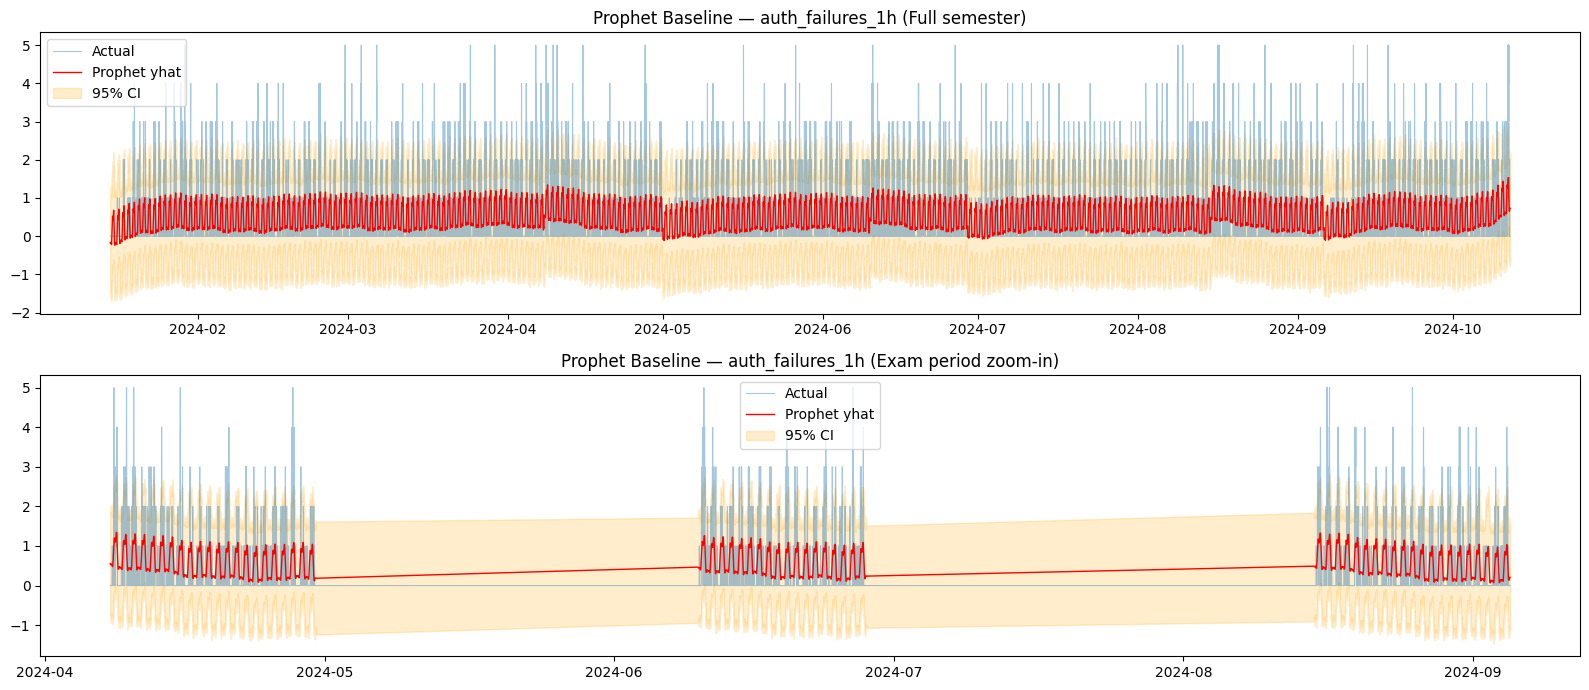

Saved: residuals.csv, prophet_models.pkl


In [63]:
# ── CELL 15 ── Calibrate Residual STDs + Compute Residuals for All Rows

normal_rows_idx = df['attack_label'] == 'NORMAL'
normal_rows     = df[normal_rows_idx].copy().set_index('timestamp')

print('Residual statistics on NORMAL rows:')
print('─' * 70)
calibrated_stds = {}
for target in PROPHET_TARGETS:
    fc         = prophet_forecasts[target]
    residuals  = normal_rows[target] - fc['yhat']
    std, p95, p99 = residuals.std(), residuals.abs().quantile(0.95), residuals.abs().quantile(0.99)
    calibrated_stds[target] = p99
    print(f'{target}')
    print(f'  std={std:>22.2f} | 95th={p95:>22.2f} | 99th={p99:>22.2f}')
    print(f'  → _RESIDUAL_STDS entry: {p99:.2f}')
    print()

joblib.dump(calibrated_stds, 'residual_stds_calibrated.pkl')

# Apply to all rows
df = df.set_index('timestamp')
for target in PROPHET_TARGETS:
    fc = prophet_forecasts[target]
    df[f'residual_{target}']     = df[target] - fc['yhat']
    df[f'outside_band_{target}'] = ((df[target] > fc['yhat_upper']) | (df[target] < fc['yhat_lower'])).astype(int)
df = df.reset_index()

band_cols      = [c for c in df.columns if c.startswith('outside_band_')]
residual_cols  = [c for c in df.columns if c.startswith('residual_')]
df['prophet_flags_sum'] = df[band_cols].sum(axis=1)

print(f'Residuals computed.')
print(f'  Rows with >= 1 band breached : {(df["prophet_flags_sum"] > 0).sum():,}')
print(f'  Rows with >= 2 bands breached: {(df["prophet_flags_sum"] >= 2).sum():,}')

# Visualise Prophet fit
target_viz = 'auth_failures_1h'
fc_viz = prophet_forecasts[target_viz].reset_index()
fig, axes = plt.subplots(2, 1, figsize=(16, 7))
for ax, sample_frac, title in [(axes[0], 1.0, 'Full semester'),
                                (axes[1], None, 'Exam period zoom-in')]:
    plot_df = df if sample_frac else df[df['is_exam_season'] == 1]
    ax.plot(plot_df['timestamp'], plot_df[target_viz], alpha=0.4, label='Actual', lw=0.8)
    fc_sub = fc_viz[fc_viz['ds'].isin(plot_df['timestamp'])]
    ax.plot(fc_sub['ds'], fc_sub['yhat'], color='red', label='Prophet yhat', lw=1.0)
    ax.fill_between(fc_sub['ds'], fc_sub['yhat_lower'], fc_sub['yhat_upper'],
                    alpha=0.2, color='orange', label='95% CI')
    ax.set_title(f'Prophet Baseline — {target_viz} ({title})')
    ax.legend()
plt.tight_layout()
plt.savefig('prophet_fit.png', dpi=130)
plt.show()

df.to_csv('residuals.csv', index=False)
print('Saved: residuals.csv, prophet_models.pkl')


---
## PHASE 4 — Isolation Forest
Trains on normal-only rows. Contamination is deliberately lower than the actual attack rate to calibrate the threshold at the 97th percentile of the normal score distribution, not the attack boundary.

In [64]:
# ── CELL 16 ── Build IF Feature Matrix + Train Isolation Forest

IF_EXTRA_COLS   = residual_cols + band_cols + ['prophet_flags_sum']
if_feature_cols = (
    [c for c in feature_cols if c in df.columns] +
    [c for c in IF_EXTRA_COLS if c in df.columns]
)
joblib.dump(if_feature_cols, 'if_feature_cols.pkl')

X_all      = df[if_feature_cols].fillna(0).values
normal_idx = (df['attack_label'] == 'NORMAL').values
X_normal   = X_all[normal_idx]
print(f'IF feature matrix : {X_all.shape}  |  Normal rows: {X_normal.shape[0]:,}')

# ── Train with contamination = 0.03 (3 % noise floor on clean traffic) ────────
IF_CONTAMINATION = 0.03

iso_forest = IsolationForest(
    n_estimators =400,     # 400 trees for more stable scores (was 300)
    contamination=IF_CONTAMINATION,
    max_samples  ='auto',
    max_features =0.9,     # feature sub-sampling → better generalisation
    bootstrap    =True,    # NEW: bootstrap sampling for variance reduction
    random_state =42,
    n_jobs       =-1,
)
iso_forest.fit(X_normal)

df['anomaly_score'] = iso_forest.decision_function(X_all)
df['anomaly_flag']  = iso_forest.predict(X_all)

CALIBRATED_THRESHOLD = iso_forest.offset_
joblib.dump(iso_forest,            'isolation_forest.pkl')
joblib.dump(CALIBRATED_THRESHOLD, 'if_calibrated_threshold.pkl')

attack_mask = df['attack_label'] != 'NORMAL'
catch_rate  = (df[attack_mask]['anomaly_flag'] == -1).mean()
fp_rate     = (df[~attack_mask]['anomaly_flag'] == -1).mean()

print(f'IF trained. calibrated_threshold = {CALIBRATED_THRESHOLD:.6f}')
print(f'Attack catch rate   : {catch_rate:.1%}')
print(f'False positive rate : {fp_rate:.1%}')
print(f'\nAnomaly flag distribution:')
print(pd.Series(df['anomaly_flag']).value_counts().to_string())


IF feature matrix : (78049, 124)  |  Normal rows: 59,890
IF trained. calibrated_threshold = -0.504603
Attack catch rate   : 22.3%
False positive rate : 3.0%

Anomaly flag distribution:
anomaly_flag
 1    72197
-1     5852


IF — Precision: 0.693 | Recall: 0.223 | F1: 0.338


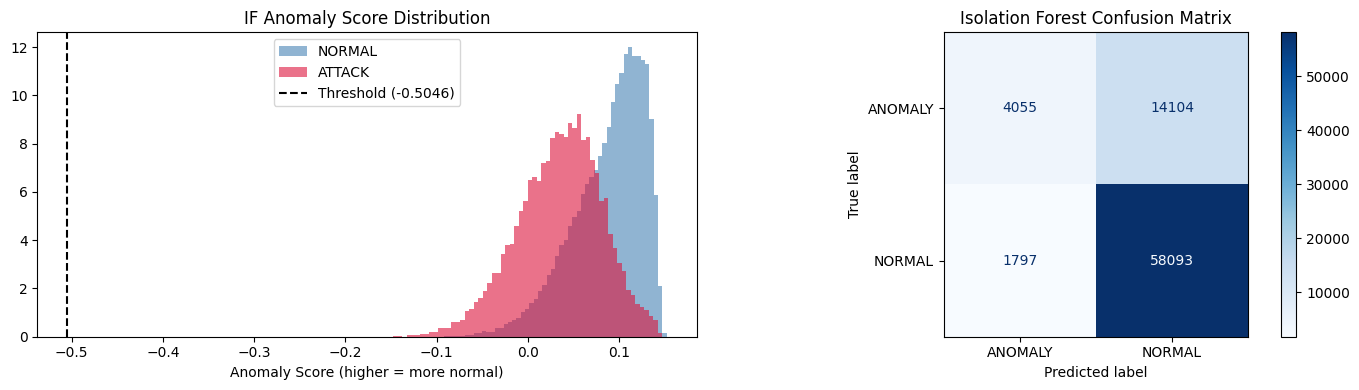


IF catch rate per attack class:
  BRUTE_FORCE              : ██████               34.9% (  916 rows)
  CREDENTIAL_STUFFING      : ███████              37.9% (  908 rows)
  PRIVILEGE_ESCALATION     : ███                  19.2% (  952 rows)
  CROSS_DEPT_ACCESS        : ███                  19.3% ( 1011 rows)
  DATA_EXFILTRATION        : ████                 24.6% ( 1042 rows)
  EXAM_FILE_TAMPERING      : ███                  16.2% ( 1038 rows)
  METADATA_BOMBING         : ███                  16.5% ( 1060 rows)
  DDOS_LAYER7              : ████████             43.3% ( 1442 rows)
  RESOURCE_EXHAUSTION      : ███                  18.8% ( 4425 rows)
  ACCOUNT_TAKEOVER         : ████                 24.0% (  908 rows)
  MASS_DELETE              : ██                   14.4% ( 1529 rows)
  GUEST_ESCALATION         : ███                  19.0% ( 1009 rows)
  OFF_HOURS_ACCESS         : ██                   12.7% (  968 rows)
  SESSION_HIJACKING        : ████                 21.7% (  951 rows)


In [65]:
# ── CELL 17 ── Isolation Forest Evaluation + Score Distribution

y_true_binary = np.where(df['attack_label'] == 'NORMAL', 1, -1)
y_pred_binary = df['anomaly_flag'].values

p_if = precision_score(y_true_binary, y_pred_binary, pos_label=-1, zero_division=0)
r_if = recall_score(   y_true_binary, y_pred_binary, pos_label=-1, zero_division=0)
f_if = f1_score(       y_true_binary, y_pred_binary, pos_label=-1, zero_division=0)
print(f'IF — Precision: {p_if:.3f} | Recall: {r_if:.3f} | F1: {f_if:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distribution by actual label
normal_scores = df[df['attack_label'] == 'NORMAL']['anomaly_score']
attack_scores = df[df['attack_label'] != 'NORMAL']['anomaly_score']
axes[0].hist(normal_scores, bins=60, alpha=0.6, label='NORMAL', color='steelblue', density=True)
axes[0].hist(attack_scores, bins=60, alpha=0.6, label='ATTACK', color='crimson',   density=True)
axes[0].axvline(CALIBRATED_THRESHOLD, color='k', linestyle='--', label=f'Threshold ({CALIBRATED_THRESHOLD:.4f})')
axes[0].set_title('IF Anomaly Score Distribution')
axes[0].legend()
axes[0].set_xlabel('Anomaly Score (higher = more normal)')

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm_if = confusion_matrix(y_true_binary, y_pred_binary, labels=[-1, 1])
ConfusionMatrixDisplay(cm_if, display_labels=['ANOMALY', 'NORMAL']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Isolation Forest Confusion Matrix')

plt.tight_layout()
plt.savefig('isolation_forest_eval.png', dpi=130)
plt.show()

# Per-class catch rate (which attack types IF is missing)
print('\nIF catch rate per attack class:')
for label in ATTACK_LABELS:
    mask = df['attack_label'] == label
    if mask.sum() == 0: continue
    caught = (df[mask]['anomaly_flag'] == -1).mean()
    bar = '█' * int(caught * 20)
    print(f'  {label:<25}: {bar:<20} {caught:.1%} ({mask.sum():>5} rows)')


---
## PHASE 5 — XGBoost Attack Classifier
Trains a multi-class XGBoost classifier on IF-flagged rows with SMOTE balancing. Includes stratified k-fold cross-validation (5 folds) for robust performance estimates and early stopping to prevent overfitting.

In [66]:
# ── CELL 18 ── Prepare XGBoost Training Set

flagged_df = df[df['anomaly_flag'] == -1].copy()
print(f'Rows passed to XGBoost: {len(flagged_df):,} of {len(df):,} total')
print('\nLabel distribution in flagged rows:')
print(flagged_df['attack_label'].value_counts().to_string())

XGB_EXTRA_COLS   = ['anomaly_score', 'prophet_flags_sum']
xgb_feature_cols = if_feature_cols + XGB_EXTRA_COLS
joblib.dump(xgb_feature_cols, 'xgb_feature_cols.pkl')

X_xgb = flagged_df[xgb_feature_cols].fillna(0).values
le    = LabelEncoder()
y_xgb = le.fit_transform(flagged_df['attack_label'])
joblib.dump(le, 'xgb_label_encoder.pkl')
print(f'\nXGBoost classes ({len(le.classes_)}): {list(le.classes_)}')


Rows passed to XGBoost: 5,852 of 78,049 total

Label distribution in flagged rows:
attack_label
NORMAL                  1797
RESOURCE_EXHAUSTION      830
DDOS_LAYER7              625
CREDENTIAL_STUFFING      344
BRUTE_FORCE              320
DATA_EXFILTRATION        256
MASS_DELETE              220
ACCOUNT_TAKEOVER         218
SESSION_HIJACKING        206
CROSS_DEPT_ACCESS        195
GUEST_ESCALATION         192
PRIVILEGE_ESCALATION     183
METADATA_BOMBING         175
EXAM_FILE_TAMPERING      168
OFF_HOURS_ACCESS         123

XGBoost classes (15): ['ACCOUNT_TAKEOVER', 'BRUTE_FORCE', 'CREDENTIAL_STUFFING', 'CROSS_DEPT_ACCESS', 'DATA_EXFILTRATION', 'DDOS_LAYER7', 'EXAM_FILE_TAMPERING', 'GUEST_ESCALATION', 'MASS_DELETE', 'METADATA_BOMBING', 'NORMAL', 'OFF_HOURS_ACCESS', 'PRIVILEGE_ESCALATION', 'RESOURCE_EXHAUSTION', 'SESSION_HIJACKING']


In [67]:
# ── CELL 19 ── Stratified K-Fold Cross-Validation (5 folds)
# Gives reliable F1/AUC estimates before final training on all data.

from sklearn.model_selection import StratifiedKFold

n_classes = len(le.classes_)

# Use a lighter model for CV speed
cv_model = xgb.XGBClassifier(
    objective        ='multi:softprob',
    num_class        =n_classes,
    n_estimators     =300,
    max_depth        =6,
    learning_rate    =0.08,
    subsample        =0.8,
    colsample_bytree =0.8,
    eval_metric      ='mlogloss',
    random_state     =42,
    n_jobs           =-1,
    verbosity        =0,
)

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1s, cv_aucs = [], []

print('Stratified 5-fold cross-validation...')
for fold, (train_idx, val_idx) in enumerate(skf.split(X_xgb, y_xgb), 1):
    X_tr, X_val = X_xgb[train_idx], X_xgb[val_idx]
    y_tr, y_val = y_xgb[train_idx], y_xgb[val_idx]

    # SMOTE on train fold only
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_tr_s, y_tr_s = smote.fit_resample(X_tr, y_tr)

    cv_model.fit(X_tr_s, y_tr_s)
    y_val_pred  = cv_model.predict(X_val)
    y_val_proba = cv_model.predict_proba(X_val)

    f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    y_val_bin = label_binarize(y_val, classes=list(range(n_classes)))
    try:
        auc = roc_auc_score(y_val_bin, y_val_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')
    cv_f1s.append(f1); cv_aucs.append(auc)
    print(f'  Fold {fold}: F1={f1:.4f}  AUC={auc:.4f}')

print(f'\nMean F1  : {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}')
print(f'Mean AUC : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')


Stratified 5-fold cross-validation...
  Fold 1: F1=0.4361  AUC=0.8719
  Fold 2: F1=0.4249  AUC=0.8717
  Fold 3: F1=0.4409  AUC=0.8717
  Fold 4: F1=0.4290  AUC=0.8678
  Fold 5: F1=0.4296  AUC=0.8693

Mean F1  : 0.4321 ± 0.0057
Mean AUC : 0.8705 ± 0.0016


In [68]:
# ── CELL 20 ── Final XGBoost Training (SMOTE + Early Stopping)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)
smote    = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)
print(f'Post-SMOTE train: {X_train.shape}  |  Test: {X_test.shape}')

xgb_model = xgb.XGBClassifier(
    objective             ='multi:softprob',
    num_class             =n_classes,
    n_estimators          =600,          # more estimators, early stopping prevents overfit
    max_depth             =7,            # slightly deeper for complex attack patterns
    learning_rate         =0.04,         # slower learning rate → better convergence
    subsample             =0.80,
    colsample_bytree      =0.75,
    colsample_bylevel     =0.75,         # NEW: column sub-sampling per tree level
    min_child_weight      =3,            # NEW: min leaf weight → prevents noisy splits
    gamma                 =0.1,          # NEW: min gain for split → regularisation
    reg_alpha             =0.1,          # L1 regularisation
    reg_lambda            =1.0,          # L2 regularisation
    eval_metric           ='mlogloss',
    early_stopping_rounds =40,
    random_state          =42,
    n_jobs                =-1,
    verbosity             =0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print(f'\nBest iteration: {xgb_model.best_iteration}')
print(f'Best score    : {xgb_model.best_score:.6f}')


Post-SMOTE train: (21570, 126)  |  Test: (1171, 126)
[0]	validation_0-mlogloss:2.60146
[100]	validation_0-mlogloss:1.21678
[173]	validation_0-mlogloss:1.21221

Best iteration: 133
Best score    : 1.201782


                      precision    recall  f1-score   support

    ACCOUNT_TAKEOVER       0.28      0.34      0.31        44
         BRUTE_FORCE       0.27      0.25      0.26        64
 CREDENTIAL_STUFFING       0.32      0.41      0.36        69
   CROSS_DEPT_ACCESS       0.29      0.33      0.31        39
   DATA_EXFILTRATION       0.44      0.55      0.49        51
         DDOS_LAYER7       0.82      0.91      0.86       125
 EXAM_FILE_TAMPERING       0.46      0.65      0.54        34
    GUEST_ESCALATION       0.30      0.34      0.32        38
         MASS_DELETE       0.43      0.55      0.48        44
    METADATA_BOMBING       0.44      0.46      0.45        35
              NORMAL       0.53      0.45      0.48       359
    OFF_HOURS_ACCESS       0.00      0.00      0.00        25
PRIVILEGE_ESCALATION       0.22      0.22      0.22        37
 RESOURCE_EXHAUSTION       0.60      0.52      0.56       166
   SESSION_HIJACKING       0.24      0.29      0.26        41

      

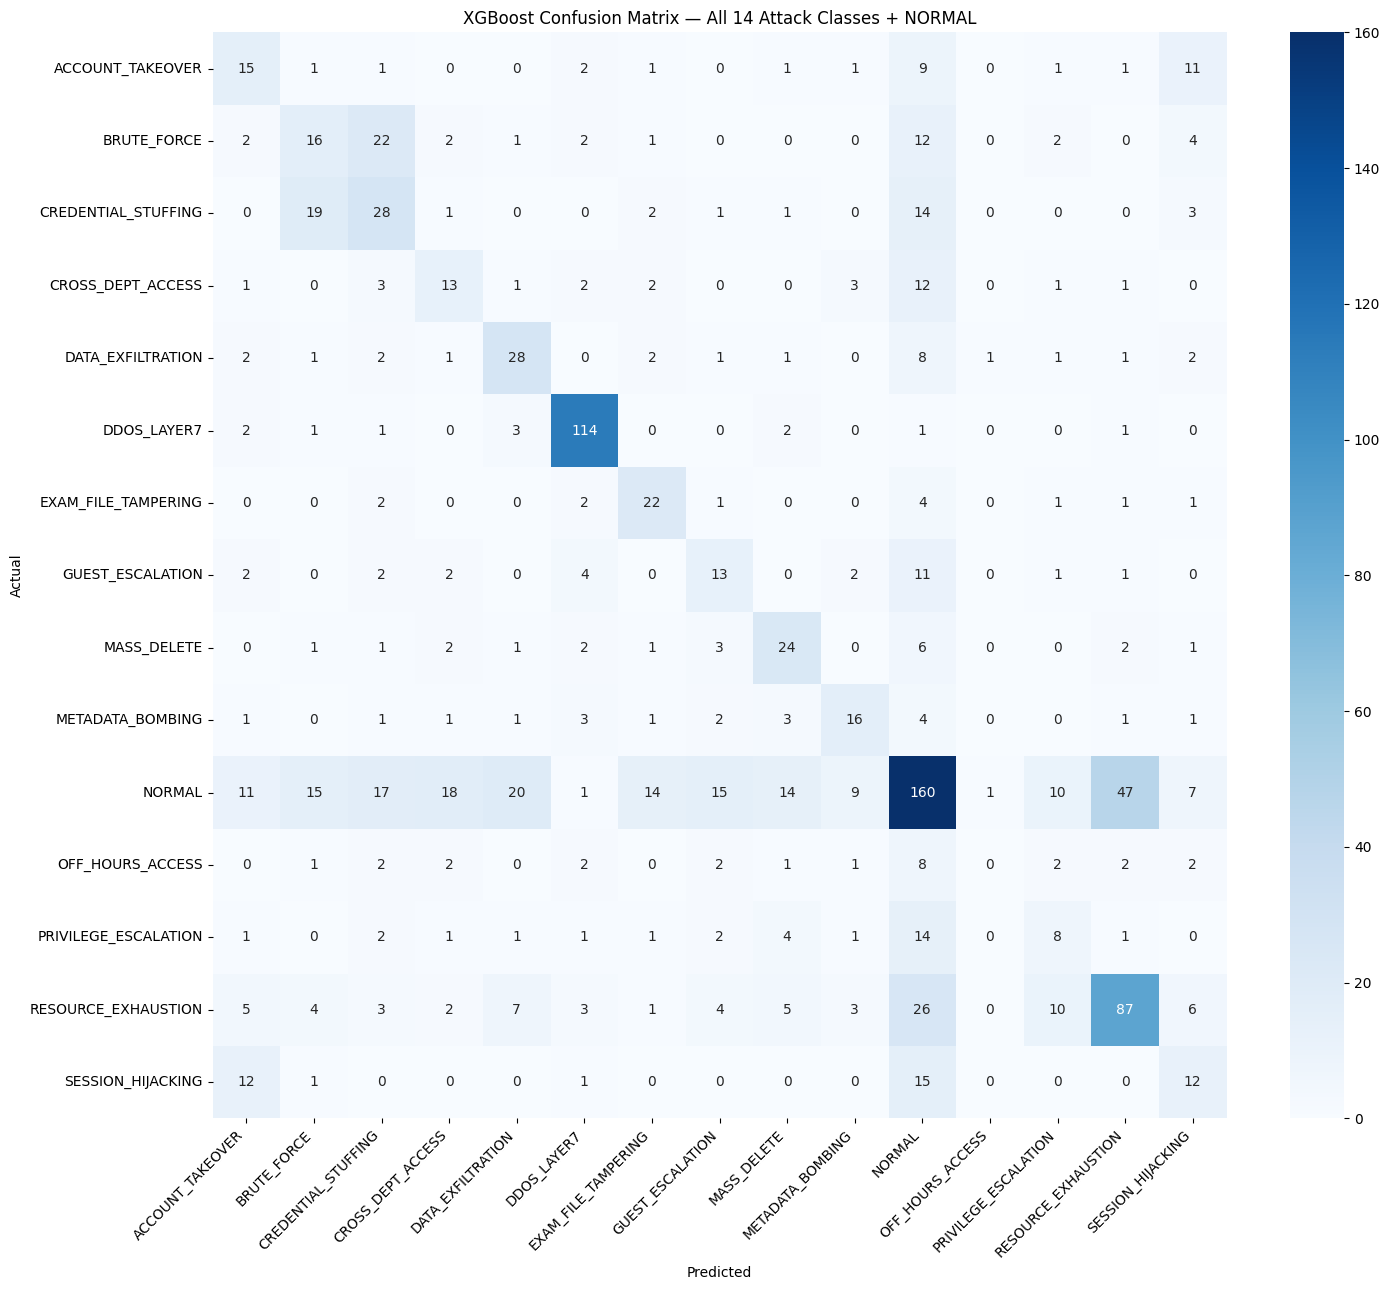

Macro ROC-AUC   : 0.9195
Weighted ROC-AUC: 0.8809


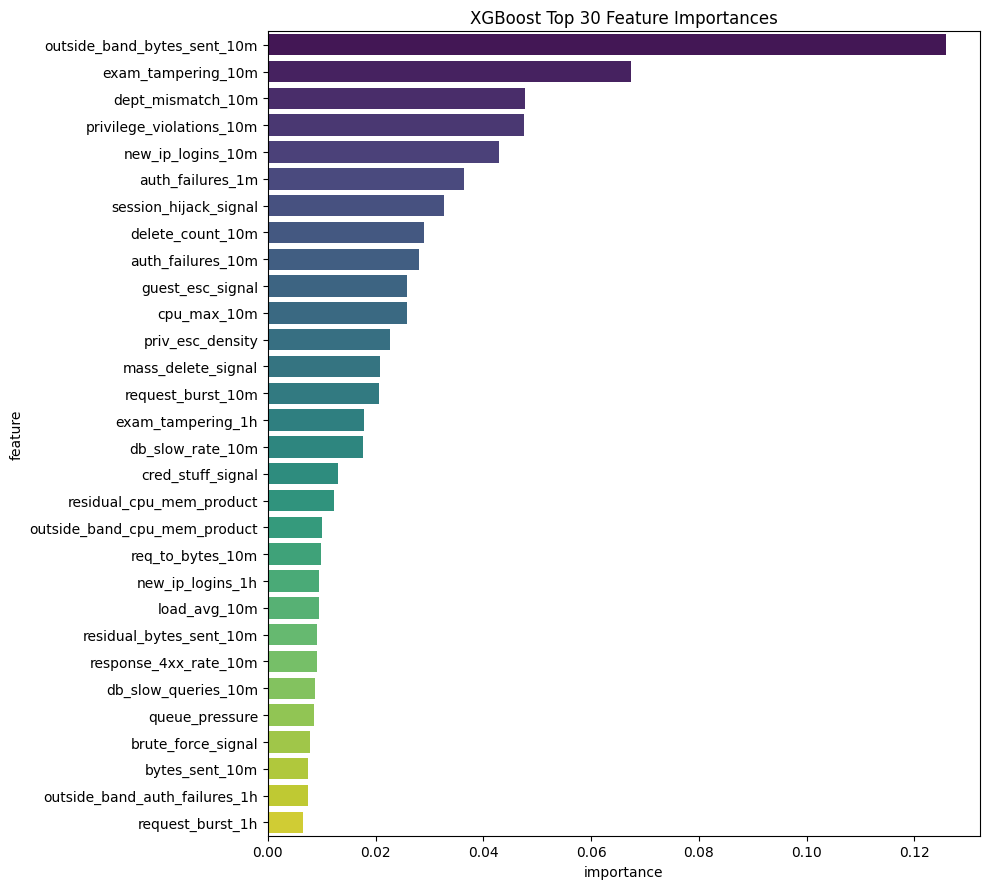

Saved: xgboost_model.pkl


In [69]:
# ── CELL 21 ── XGBoost Evaluation

y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('XGBoost Confusion Matrix — All 14 Attack Classes + NORMAL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=130)
plt.show()

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
print(f'Macro ROC-AUC   : {roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro"):.4f}')
print(f'Weighted ROC-AUC: {roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted"):.4f}')

# Feature importance — top 30
imp_df = pd.DataFrame({'feature': xgb_feature_cols, 'importance': xgb_model.feature_importances_}
).sort_values('importance', ascending=False).head(30)
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, palette='viridis')
ax.set_title('XGBoost Top 30 Feature Importances')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=130)
plt.show()

joblib.dump(xgb_model, 'xgboost_model.pkl')
print('Saved: xgboost_model.pkl')


In [70]:
# ── CELL 22 ── Per-Class Decision Threshold Optimisation
# Instead of a single global threshold, find the confidence threshold that
# maximises F1 for each attack class independently.

from sklearn.metrics import precision_recall_curve

optimal_thresholds = {}
print('Per-class optimal confidence thresholds (maximising F1):')
print('─' * 60)

for idx, class_name in enumerate(le.classes_):
    y_binary   = (y_test == idx).astype(int)
    y_score    = y_proba[:, idx]
    prec, rec, thr = precision_recall_curve(y_binary, y_score)
    f1_scores  = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx   = np.argmax(f1_scores[:-1])  # last element has no threshold
    best_thr   = float(thr[best_idx])
    best_f1    = float(f1_scores[best_idx])
    optimal_thresholds[class_name] = best_thr
    print(f'  {class_name:<28}: threshold={best_thr:.3f}  F1={best_f1:.3f}')

joblib.dump(optimal_thresholds, 'xgb_optimal_thresholds.pkl')
print('\nSaved: xgb_optimal_thresholds.pkl')
print('These thresholds replace the single xgb_threshold in SensitivityProfiler.PROFILES for precision-tuned inference.')


Per-class optimal confidence thresholds (maximising F1):
────────────────────────────────────────────────────────────
  ACCOUNT_TAKEOVER            : threshold=0.144  F1=0.420
  BRUTE_FORCE                 : threshold=0.078  F1=0.430
  CREDENTIAL_STUFFING         : threshold=0.121  F1=0.481
  CROSS_DEPT_ACCESS           : threshold=0.096  F1=0.410
  DATA_EXFILTRATION           : threshold=0.217  F1=0.554
  DDOS_LAYER7                 : threshold=0.235  F1=0.884
  EXAM_FILE_TAMPERING         : threshold=0.149  F1=0.617
  GUEST_ESCALATION            : threshold=0.197  F1=0.486
  MASS_DELETE                 : threshold=0.416  F1=0.527
  METADATA_BOMBING            : threshold=0.136  F1=0.580
  NORMAL                      : threshold=0.279  F1=0.557
  OFF_HOURS_ACCESS            : threshold=0.054  F1=0.103
  PRIVILEGE_ESCALATION        : threshold=0.065  F1=0.372
  RESOURCE_EXHAUSTION         : threshold=0.263  F1=0.626
  SESSION_HIJACKING           : threshold=0.137  F1=0.391

Saved: xgb_

---
## PHASE 6 — Calibration & Model Audit
Applies Platt scaling to XGBoost probability outputs (overconfident by default). Runs SHAP feature importance for interpretability. Generates UMAP cluster visualisation of the anomaly space.

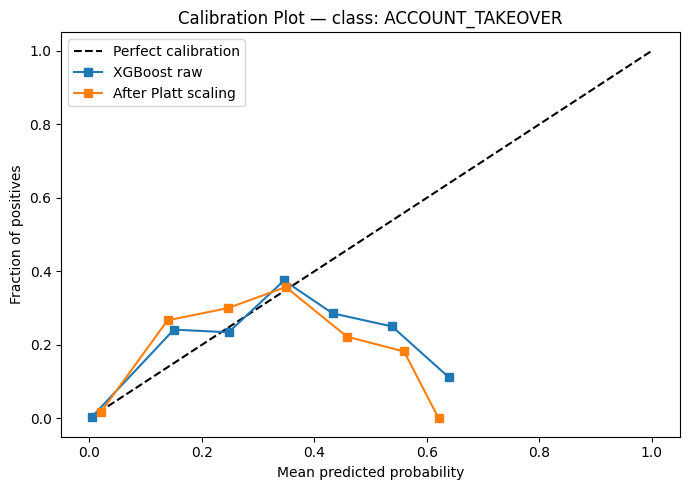

Calibrated model saved: xgboost_calibrated.pkl


In [71]:
# ── CELL 23 ── Probability Calibration (Platt Scaling)
# XGBoost softmax probabilities tend to be overconfident.
# CalibratedClassifierCV with method='sigmoid' corrects this.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrate on the hold-out test set
calibrated_xgb = CalibratedClassifierCV(xgb_model, method='sigmoid', cv='prefit')
calibrated_xgb.fit(X_test, y_test)

y_proba_cal = calibrated_xgb.predict_proba(X_test)

# Compare calibration for class 0 (BRUTE_FORCE or first class)
class_idx = 0
raw_proba  = y_proba[:, class_idx]
cal_proba  = y_proba_cal[:, class_idx]
y_binary   = (y_test == class_idx).astype(int)

frac_pos_raw, mean_pred_raw = calibration_curve(y_binary, raw_proba,  n_bins=10, strategy='uniform')
frac_pos_cal, mean_pred_cal = calibration_curve(y_binary, cal_proba,  n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, 's-', label='XGBoost raw')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', label='After Platt scaling')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration Plot — class: {le.classes_[class_idx]}')
ax.legend()
plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=130)
plt.show()

joblib.dump(calibrated_xgb, 'xgboost_calibrated.pkl')
print('Calibrated model saved: xgboost_calibrated.pkl')


SHAP skipped: Per-column arrays must each be 1-dimensional


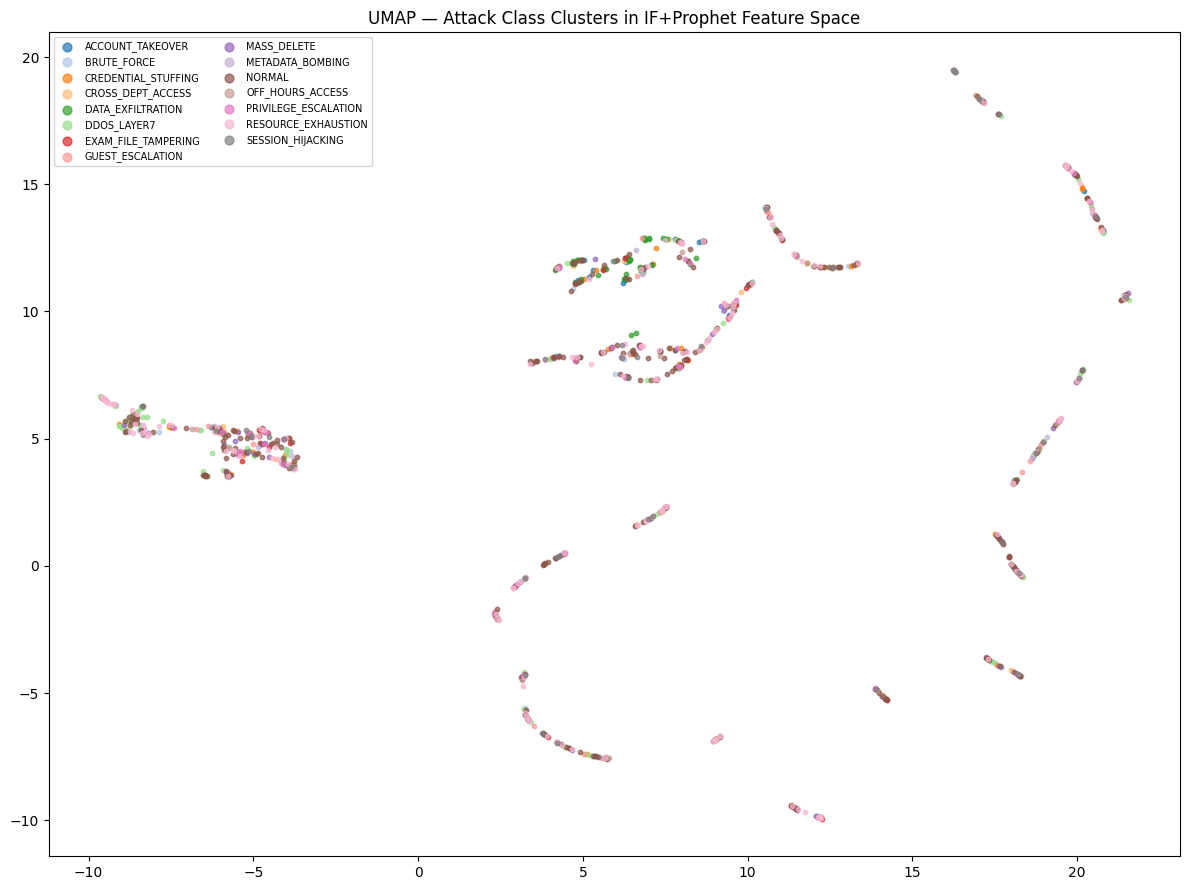

UMAP cluster plot saved.


In [72]:
# ── CELL 24 ── SHAP Feature Importance + UMAP Cluster Visualisation

try:
    import shap

    # SHAP on a sample for speed
    sample_idx = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
    explainer  = shap.TreeExplainer(xgb_model)
    shap_vals  = explainer.shap_values(X_test[sample_idx])  # list of arrays, one per class

    # Mean absolute SHAP across all classes
    if isinstance(shap_vals, list):
        mean_shap = np.mean([np.abs(sv) for sv in shap_vals], axis=0).mean(axis=0)
    else:
        mean_shap = np.abs(shap_vals).mean(axis=0)

    shap_df = pd.DataFrame({'feature': xgb_feature_cols[:len(mean_shap)], 'mean_abs_shap': mean_shap}
    ).sort_values('mean_abs_shap', ascending=False).head(30)

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.barplot(data=shap_df, x='mean_abs_shap', y='feature', ax=ax, palette='magma')
    ax.set_title('SHAP — Mean |SHAP| Feature Importance (Top 30, averaged across classes)')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=130)
    plt.show()
    print('SHAP importance plot saved.')
except Exception as e:
    print(f'SHAP skipped: {e}')

# UMAP cluster visualisation
try:
    from umap import UMAP

    sample_n = min(3000, len(X_test))
    sample_idx_u = np.random.choice(len(X_test), size=sample_n, replace=False)
    X_sample = X_test[sample_idx_u]
    y_sample = y_test[sample_idx_u]

    reducer   = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X_sample)

    fig, ax = plt.subplots(figsize=(12, 9))
    classes = le.classes_
    palette = sns.color_palette('tab20', n_colors=len(classes))
    for i, cls in enumerate(classes):
        mask = y_sample == i
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=10, alpha=0.7,
                   label=cls, color=palette[i])
    ax.set_title('UMAP — Attack Class Clusters in IF+Prophet Feature Space')
    ax.legend(fontsize=7, ncol=2, markerscale=2)
    plt.tight_layout()
    plt.savefig('umap_clusters.png', dpi=130)
    plt.show()
    print('UMAP cluster plot saved.')
except Exception as e:
    print(f'UMAP skipped: {e}')


---
## PHASE 7 — SensitivityProfiler + Inference Demo
The `SensitivityProfiler` wraps all three layers into a context-aware inference interface with dynamic thresholding. Includes all 6 demo blocks (A-F) covering attack detection, context sensitivity, stealth attacks, grading-window attacks, false-positive verification, and suspicious behaviour review.

In [73]:
# ── CELL 25 ── SensitivityProfiler Class (v2 — calibrated probabilities + per-class thresholds)

class SensitivityProfiler:
    """
    3-layer context-aware inference pipeline.

    Pipeline:
      Layer 1 — Prophet: residuals + band-breach flags; short-circuit if signal extreme.
      Layer 2 — Isolation Forest: anomaly score with context-shifted threshold.
      Layer 3 — XGBoost (calibrated): attack classification with per-class thresholds.

    Context keys:
      current_season  : 'normal' | 'exam' | 'grading'
      time_of_day     : 'business_hours' | 'evening' | 'night'
      day_type        : 'weekday' | 'weekend'
      active_incident : bool
    """

    PROFILES = {
        'active_incident': {'if_contamination': 0.01, 'xgb_threshold': 0.40, 'prophet_interval': 0.70},
        'exam_season'    : {'if_contamination': 0.08, 'xgb_threshold': 0.75, 'prophet_interval': 1.50},
        'grading_window' : {'if_contamination': 0.06, 'xgb_threshold': 0.70, 'prophet_interval': 1.30},
        'night_weekend'  : {'if_contamination': 0.01, 'xgb_threshold': 0.50, 'prophet_interval': 0.80},
        'normal_weekday' : {'if_contamination': 0.03, 'xgb_threshold': 0.60, 'prophet_interval': 1.00},
    }

    _TRAINING_CONTAMINATION = 0.03
    PROPHET_RESIDUAL_Z_THRESH = 4.0
    PROPHET_OVERRIDE_BANDS    = 2
    SUSPICION_THRESHOLD       = 5.5

    def __init__(self, prophet_models, iso_forest, xgb_model, if_feature_cols,
                 xgb_feature_cols, label_encoder, calibrated_threshold,
                 residual_stds=None, optimal_thresholds=None):
        self.prophet_models       = prophet_models
        self.iso_forest           = iso_forest
        self.xgb_model            = xgb_model
        self.if_feature_cols      = if_feature_cols
        self.xgb_feature_cols     = xgb_feature_cols
        self.le                   = label_encoder
        self.calibrated_threshold = calibrated_threshold
        self._RESIDUAL_STDS       = residual_stds or joblib.load('residual_stds_calibrated.pkl')
        self.optimal_thresholds   = optimal_thresholds or {}

    def _resolve_profile(self, ctx):
        if ctx.get('active_incident'): return self.PROFILES['active_incident']
        s, t, d = ctx.get('current_season','normal'), ctx.get('time_of_day','business_hours'), ctx.get('day_type','weekday')
        if s == 'exam':    return self.PROFILES['exam_season']
        if s == 'grading': return self.PROFILES['grading_window']
        if t == 'night' or d == 'weekend': return self.PROFILES['night_weekend']
        return self.PROFILES['normal_weekday']

    def _apply_prophet(self, row_df, interval_multiplier):
        row_df, flags = row_df.copy(), 0
        for target, model in self.prophet_models.items():
            if target not in row_df.columns: continue
            fc         = model.predict(row_df[['timestamp']].rename(columns={'timestamp': 'ds'}))
            yhat       = fc['yhat'].values
            half_width = (fc['yhat_upper'].values - fc['yhat_lower'].values) / 2
            actual     = row_df[target].values
            outside    = int(((actual > yhat + half_width * interval_multiplier) |
                              (actual < yhat - half_width * interval_multiplier))[0])
            row_df[f'residual_{target}']     = actual - yhat
            row_df[f'outside_band_{target}'] = outside
            flags += outside
        row_df['prophet_flags_sum'] = flags
        return row_df

    def _prophet_short_circuit(self, enriched):
        outside_bands = int(enriched['prophet_flags_sum'].iloc[0])
        if outside_bands >= self.PROPHET_OVERRIDE_BANDS:
            return True, f'prophet_multi_band_breach({outside_bands}_bands)'
        # z-score check uses raw residual stds — NOT scaled by interval_multiplier.
        # This ensures extreme residuals (e.g. massive bytes_sent during exfiltration)
        # always trigger regardless of the season's wider Prophet band.
        for target, std in self._RESIDUAL_STDS.items():
            col = f'residual_{target}'
            if col not in enriched.columns: continue
            z = abs(float(enriched[col].iloc[0])) / max(std, 1e-9)
            if z >= self.PROPHET_RESIDUAL_Z_THRESH:
                return True, f'prophet_extreme_residual({target}, z={z:.1f})'
        if 'user_suspicion_score' in enriched.columns:
            score = float(enriched['user_suspicion_score'].iloc[0])
            if score >= self.SUSPICION_THRESHOLD:
                return True, f'user_behavioural_suspicion(score={score:.2f})'
        return False, ''

    def _run_isolation_forest(self, enriched, profile):
        X_if      = enriched[self.if_feature_cols].fillna(0).values
        raw_score = float(self.iso_forest.decision_function(X_if)[0])
        delta     = profile['if_contamination'] - self._TRAINING_CONTAMINATION
        # CORRECTED: higher contamination (lenient seasons like exam) → raise threshold
        # so fewer rows are flagged. Lower contamination (strict modes like active_incident
        # or night) → lower threshold so more rows are flagged.
        # delta is positive for exam/grading (raise threshold = less sensitive) ✓
        # delta is negative for active_incident/night (lower threshold = more sensitive) ✓
        adj_thr   = self.calibrated_threshold + delta * 0.5
        return raw_score, (-1 if raw_score < adj_thr else 1)

    def predict(self, row_df, context):
        profile  = self._resolve_profile(context)
        enriched = self._apply_prophet(row_df, profile['prophet_interval'])
        residuals_out = {t: float(enriched[f'residual_{t}'].iloc[0])
                         for t in self.prophet_models if f'residual_{t}' in enriched.columns}
        outside_bands = int(enriched['prophet_flags_sum'].iloc[0])

        prophet_override, override_reason = self._prophet_short_circuit(enriched)
        if prophet_override:
            raw_score, anomaly_flag = None, -1
        else:
            raw_score, anomaly_flag = self._run_isolation_forest(enriched, profile)

        if anomaly_flag == -1:
            X_xgb = enriched[self.xgb_feature_cols].fillna(0).values
            proba  = self.xgb_model.predict_proba(X_xgb)[0]
            all_probs = {cls: float(p) for cls, p in zip(self.le.classes_, proba)}
            top_idx   = int(np.argmax(proba))
            top_prob  = float(proba[top_idx])
            cls_name  = self.le.classes_[top_idx]
            # Use per-class optimal threshold if available, else profile threshold
            threshold = self.optimal_thresholds.get(cls_name, profile['xgb_threshold'])
            predicted_class = cls_name if top_prob >= threshold else f'LOW_CONF_{cls_name}'
            confidence = top_prob
        else:
            all_probs, predicted_class, confidence = {c: 0.0 for c in self.le.classes_}, 'NORMAL', 1.0

        return {
            'layer1_residuals': residuals_out, 'layer1_outside_bands': outside_bands,
            'layer1_prophet_override': prophet_override, 'layer1_override_reason': override_reason,
            'layer2_anomaly_score': raw_score, 'layer2_anomaly_flag': anomaly_flag,
            'layer3_attack_class': predicted_class, 'layer3_confidence': confidence,
            'layer3_all_probs': all_probs, 'active_profile': profile,
        }


profiler = SensitivityProfiler(
    prophet_models       = prophet_models,
    iso_forest           = iso_forest,
    xgb_model            = calibrated_xgb,
    if_feature_cols      = if_feature_cols,
    xgb_feature_cols     = xgb_feature_cols,
    label_encoder        = le,
    calibrated_threshold = joblib.load('if_calibrated_threshold.pkl'),
    residual_stds        = joblib.load('residual_stds_calibrated.pkl'),
    optimal_thresholds   = joblib.load('xgb_optimal_thresholds.pkl'),
)
joblib.dump(profiler, 'sensitivity_profiler.pkl')
print('SensitivityProfiler (v2) instantiated and saved.')

SensitivityProfiler (v2) instantiated and saved.


In [74]:
# ── CELL 26 ── Inference Demo — Blocks A through F

def _print_result(result):
    print('\n[Layer 1 — Prophet]')
    for t, r in result['layer1_residuals'].items():
        print(f'  residual_{t}: {r:+.4f}')
    print(f'  Bands breached: {result["layer1_outside_bands"]}')
    if result['layer1_prophet_override']:
        print(f'  ⚡ SHORT-CIRCUIT: {result["layer1_override_reason"]}')
    print('\n[Layer 2 — Isolation Forest]')
    if result['layer2_anomaly_score'] is None:
        print('  Skipped — Prophet override active.')
    else:
        print(f'  Anomaly score : {result["layer2_anomaly_score"]:+.6f}')
    flag_str = '🔴 ANOMALY (-1)' if result['layer2_anomaly_flag'] == -1 else '🟢 NORMAL (1)'
    print(f'  Anomaly flag  : {flag_str}')
    print('\n[Layer 3 — XGBoost]')
    if result['layer2_anomaly_flag'] == -1:
        print(f'  Predicted class: {result["layer3_attack_class"]}')
        print(f'  Confidence     : {result["layer3_confidence"]:.4f}')
        print('  Top-5 probabilities:')
        for cls, prob in sorted(result['layer3_all_probs'].items(), key=lambda x: -x[1])[:5]:
            bar = '█' * int(prob * 30)
            print(f'    {bar:<30} {prob:.3f}  {cls}')
    else:
        print('  Not reached — correctly suppressed.')
    print(f'\n  Active profile: {result["active_profile"]}')
    print('=' * 60)

def run_attack_demo(attack_label, context, note='', seed=42):
    candidates = df[(df['attack_label'] == attack_label) & (df['anomaly_flag'] == -1)]
    if len(candidates) == 0:
        candidates = df[df['attack_label'] == attack_label]
    row = candidates.sample(1, random_state=seed).copy()
    print(f'\n{"="*60}\n  ATTACK DEMO — {attack_label}')
    if note: print(f'  Scenario: {note}')
    print(f'  Context : {context}\n{"="*60}')
    _print_result(profiler.predict(row, context))

def run_normal_demo(context, note='', seed=42):
    row = df[df['attack_label'] == 'NORMAL'].sample(1, random_state=seed).copy()
    print(f'\n{"="*60}\n  NORMAL CHECK')
    if note: print(f'  Scenario: {note}')
    print(f'  Context : {context}\n{"="*60}')
    result = profiler.predict(row, context)
    print('\n[Layer 1 — Prophet]')
    for t, r in result['layer1_residuals'].items(): print(f'  residual_{t}: {r:+.4f}')
    print(f'  Bands breached: {result["layer1_outside_bands"]}')
    if result['layer1_prophet_override']:
        print(f'  ⚠️  FALSE POSITIVE — SHORT-CIRCUIT on clean row: {result["layer1_override_reason"]}')
    print('\n[Layer 2 — Isolation Forest]')
    if result['layer2_anomaly_score'] is not None:
        print(f'  Anomaly score: {result["layer2_anomaly_score"]:+.6f}')
    result_str = '🔴 FALSE POSITIVE' if result['layer2_anomaly_flag'] == -1 else '🟢 CORRECTLY NORMAL'
    print(f'  Result: {result_str}')
    print('\n[Layer 3 — XGBoost]')
    if result['layer2_anomaly_flag'] == -1:
        print(f'  Wrongly classified as: {result["layer3_attack_class"]}')
        print(f'  Confidence: {result["layer3_confidence"]:.4f}')
    else:
        print('  Not reached — correctly suppressed.')
    print(f'\n  Active profile: {result["active_profile"]}')
    print('=' * 60)

def run_suspicious_demo(context, note='', seed=42):
    candidates = df[df['attack_label'] == 'OFF_HOURS_ACCESS']
    if len(candidates) == 0: print('No OFF_HOURS_ACCESS rows found.'); return
    row    = candidates.sample(1, random_state=seed).copy()
    result = profiler.predict(row, context)
    print(f'\n{"="*60}\n  SUSPICIOUS BEHAVIOUR CHECK')
    if note: print(f'  Scenario: {note}')
    print(f'  Context : {context}\n{"="*60}')
    print('\n[Layer 1 — Prophet]')
    for t, r in result['layer1_residuals'].items(): print(f'  residual_{t}: {r:+.4f}')
    print(f'  Bands breached: {result["layer1_outside_bands"]}')
    if result['layer1_prophet_override']:
        print(f'  ⚡ SHORT-CIRCUIT: {result["layer1_override_reason"]}')
    print('\n[Layer 2 — Isolation Forest]')
    if result['layer2_anomaly_score'] is None:
        print('  Skipped — Prophet override active.')
    else:
        print(f'  Anomaly score: {result["layer2_anomaly_score"]:+.6f}')
    flag_str = '🟡 FLAGGED FOR REVIEW' if result['layer2_anomaly_flag'] == -1 else '🟢 PASSED (not flagged)'
    print(f'  Result: {flag_str}')
    print('\n[Layer 3 — XGBoost]')
    if result['layer2_anomaly_flag'] == -1:
        cls, conf = result['layer3_attack_class'], result['layer3_confidence']
        if cls == 'NORMAL':
            verdict = '🟡 Signal strength flagged but no attack pattern — log and monitor'
        elif cls.startswith('LOW_CONF'):
            verdict = '⚠️  LOW CONFIDENCE — Add to human review queue, do not auto-block'
        else:
            verdict = '🔴 Confirmed attack classification — escalate'
        print(f'  Classification: {cls}\n  Confidence    : {conf:.4f}\n  Verdict       : {verdict}')
        print('  Top-5 probabilities:')
        for cls_p, prob in sorted(result['layer3_all_probs'].items(), key=lambda x: -x[1])[:5]:
            bar = '█' * int(prob * 30)
            print(f'    {bar:<30} {prob:.3f}  {cls_p}')
    else:
        print('  Not flagged — treated as normal.\n  Verdict: 🟢 No action required.')
    print(f'\n  Active profile: {result["active_profile"]}')
    print('=' * 60)


# ── BLOCK A — Regression baseline attacks ────────────────────────────────────
run_attack_demo('DATA_EXFILTRATION',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Bulk GET during normal hours — Prophet band breach')
run_attack_demo('BRUTE_FORCE',
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekday', 'active_incident': False},
    note='Auth flood at night — strict night profile')
run_attack_demo('EXAM_FILE_TAMPERING',
    {'current_season': 'exam', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='PUT to exams/ during exam season — high XGB threshold (0.75)')
run_attack_demo('DDOS_LAYER7',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': True},
    note='Active incident declared — tightest profile, lowest XGB threshold (0.40)')

# ── BLOCK B — Context sensitivity ────────────────────────────────────────────
run_attack_demo('BRUTE_FORCE',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='BRUTE_FORCE during business hours — normal_weekday profile')
run_attack_demo('DATA_EXFILTRATION',
    {'current_season': 'exam', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='DATA_EXFILTRATION during exam season — wider Prophet band, higher XGB threshold')
run_attack_demo('DATA_EXFILTRATION',
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekend', 'active_incident': False},
    note='DATA_EXFILTRATION on weekend night — any traffic is suspicious')
run_attack_demo('DDOS_LAYER7',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='DDoS without active incident — normal_weekday profile', seed=99)

# ── BLOCK C — Stealth / low-signal attacks ───────────────────────────────────
run_attack_demo('CREDENTIAL_STUFFING',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Many IPs, low per-IP rate — relies on IAM rolling features')
run_attack_demo('PRIVILEGE_ESCALATION',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='403s on admin routes — subtle IAM pattern')
run_attack_demo('CROSS_DEPT_ACCESS',
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='CS professor hitting MECH container — dept_mismatch signal')

# ── BLOCK D — Grading window attacks ─────────────────────────────────────────
run_attack_demo('ACCOUNT_TAKEOVER',
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekday', 'active_incident': False},
    note='Valid login from new IP at night — is_new_ip + off-hours')
run_attack_demo('MASS_DELETE',
    {'current_season': 'grading', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Bulk DELETE during grading window — elevated write activity is normal, must still flag')
run_attack_demo('GUEST_ESCALATION',
    {'current_season': 'grading', 'time_of_day': 'evening', 'day_type': 'weekday', 'active_incident': False},
    note='Guest accessing wrong department during grading')

# ── BLOCK E — Normal false-positive checks ────────────────────────────────────
run_normal_demo(
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Regular professor — own dept, business hours', seed=42)
run_normal_demo(
    {'current_season': 'exam', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Exam season — heavy traffic should NOT trigger', seed=99)
run_normal_demo(
    {'current_season': 'grading', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Grading window — teachers uploading marks, elevated PUT is expected', seed=7)
run_normal_demo(
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekend', 'active_incident': False},
    note='SuperAdmin maintenance at night — rare but legitimate', seed=15)
run_normal_demo(
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='HOD cross-subdir read within own department', seed=200)

# ── BLOCK F — Suspicious behaviour review ────────────────────────────────────
run_suspicious_demo(
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekday', 'active_incident': False},
    note='Valid login at 2 AM on weeknight — credentials correct, time unusual', seed=42)
run_suspicious_demo(
    {'current_season': 'normal', 'time_of_day': 'night', 'day_type': 'weekend', 'active_incident': False},
    note='Valid login at 3 AM on Sunday — strictest profile', seed=55)
run_suspicious_demo(
    {'current_season': 'exam', 'time_of_day': 'night', 'day_type': 'weekday', 'active_incident': False},
    note='Exam season night access — staff may legitimately work late', seed=77)
run_suspicious_demo(
    {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False},
    note='Slightly elevated request rate — not attack volume, just above baseline', seed=101)
run_suspicious_demo(
    {'current_season': 'grading', 'time_of_day': 'evening', 'day_type': 'weekday', 'active_incident': False},
    note='College admin browsing multiple departments late evening during grading', seed=13)



  ATTACK DEMO — DATA_EXFILTRATION
  Scenario: Bulk GET during normal hours — Prophet band breach
  Context : {'current_season': 'normal', 'time_of_day': 'business_hours', 'day_type': 'weekday', 'active_incident': False}

[Layer 1 — Prophet]
  residual_auth_failures_1h: +1.1344
  residual_bytes_sent_10m: +15046987447.1103
  residual_cpu_mem_product: +0.0382
  residual_head_count_10m: -0.6020
  Bands breached: 1
  ⚡ SHORT-CIRCUIT: user_behavioural_suspicion(score=22.17)

[Layer 2 — Isolation Forest]
  Skipped — Prophet override active.
  Anomaly flag  : 🔴 ANOMALY (-1)

[Layer 3 — XGBoost]
  Predicted class: DATA_EXFILTRATION
  Confidence     : 0.6316
  Top-5 probabilities:
    ██████████████████             0.632  DATA_EXFILTRATION
    ████                           0.159  NORMAL
    █                              0.041  RESOURCE_EXHAUSTION
                                   0.019  OFF_HOURS_ACCESS
                                   0.018  BRUTE_FORCE

  Active profile: {'if_contaminati

---
## PHASE 8 — Final Export
Scores all rows, exports `scored_logs.csv`, and prints a full artifact manifest.

In [75]:
# ── CELL 27 ── Score All Rows + Final Export + Artifact Manifest

anomaly_rows  = df[df['anomaly_flag'] == -1].copy()
X_all_flagged = anomaly_rows[xgb_feature_cols].fillna(0).values
proba_all     = calibrated_xgb.predict_proba(X_all_flagged)
pred_idx      = np.argmax(proba_all, axis=1)
pred_conf     = np.max(proba_all,    axis=1)

df.loc[df['anomaly_flag'] == -1, 'predicted_attack_class'] = le.inverse_transform(pred_idx)
df.loc[df['anomaly_flag'] == -1, 'xgb_confidence']         = pred_conf
df.loc[df['anomaly_flag'] ==  1, 'predicted_attack_class'] = 'NORMAL'
df.loc[df['anomaly_flag'] ==  1, 'xgb_confidence']         = 1.0

df.to_csv('scored_logs.csv', index=False)
print(f'scored_logs.csv saved — {len(df):,} rows')
print('\nPredicted class distribution:')
print(df['predicted_attack_class'].value_counts().to_string())

ARTIFACTS = [
    # ── Models
    ('prophet_models.pkl',           'Prophet seasonal baseline (Layer 1)'),
    ('isolation_forest.pkl',         'Isolation Forest anomaly detector (Layer 2)'),
    ('if_calibrated_threshold.pkl',  'IF context-shifted decision threshold'),
    ('xgboost_model.pkl',            'XGBoost raw attack classifier (Layer 3)'),
    ('xgboost_calibrated.pkl',       'XGBoost + Platt scaling calibration'),
    ('sensitivity_profiler.pkl',     'SensitivityProfiler — full pipeline v2'),
    # ── Encoders + metadata
    ('xgb_label_encoder.pkl',        'XGBoost label encoder'),
    ('xgb_optimal_thresholds.pkl',   'Per-class optimal confidence thresholds'),
    ('if_feature_cols.pkl',          'IF feature column list'),
    ('xgb_feature_cols.pkl',         'XGBoost feature column list'),
    ('feature_cols.pkl',             'Base feature column list'),
    ('label_encoder.pkl',            'Phase 2 label encoder'),
    ('residual_stds_calibrated.pkl', 'Calibrated residual z-score stds'),
    # ── Data files
    ('keystone_logs.csv',            'Raw Keystone logs (75 k rows)'),
    ('swift_proxy_logs.csv',         'Raw Swift Proxy logs (90 k rows)'),
    ('swift_server_logs.csv',        'Raw Swift Server logs (45 k rows)'),
    ('system_logs.csv',              'Raw System Resource logs'),
    ('mariadb_logs.csv',             'Raw MariaDB logs (40 k rows)'),
    ('rabbitmq_logs.csv',            'Raw RabbitMQ logs'),
    ('unified_logs.csv',             'Joined 5-min window logs'),
    ('ml_ready.csv',                 'Feature-engineered matrix (113 features)'),
    ('residuals.csv',                'Prophet residuals + IF anomaly scores'),
    ('scored_logs.csv',              'Final predictions (all rows)'),
    # ── Plots
    ('prophet_fit.png',              'Prophet baseline fit (full + exam zoom)'),
    ('isolation_forest_eval.png',    'IF score distribution + confusion matrix'),
    ('xgboost_confusion_matrix.png', 'XGBoost confusion matrix (14 classes)'),
    ('xgboost_feature_importance.png','XGBoost top-30 feature importances'),
    ('calibration_plot.png',         'Probability calibration before/after Platt scaling'),
    ('shap_importance.png',          'SHAP mean |SHAP| importance (if SHAP installed)'),
    ('umap_clusters.png',            'UMAP 2D cluster plot (if umap-learn installed)'),
]
print('\n' + '=' * 65)
print('  ARTIFACT MANIFEST')
print('=' * 65)
for fname, desc in ARTIFACTS:
    status = '✓' if os.path.exists(fname) else '✗ MISSING'
    print(f'  {status}  {fname:<48s} {desc}')


scored_logs.csv saved — 78,049 rows

Predicted class distribution:
predicted_attack_class
NORMAL                  74135
RESOURCE_EXHAUSTION       804
DDOS_LAYER7               635
CREDENTIAL_STUFFING       360
BRUTE_FORCE               320
DATA_EXFILTRATION         253
ACCOUNT_TAKEOVER          222
SESSION_HIJACKING         205
MASS_DELETE               200
CROSS_DEPT_ACCESS         186
GUEST_ESCALATION          180
METADATA_BOMBING          177
EXAM_FILE_TAMPERING       173
PRIVILEGE_ESCALATION      163
OFF_HOURS_ACCESS           36

  ARTIFACT MANIFEST
  ✓  prophet_models.pkl                               Prophet seasonal baseline (Layer 1)
  ✓  isolation_forest.pkl                             Isolation Forest anomaly detector (Layer 2)
  ✓  if_calibrated_threshold.pkl                      IF context-shifted decision threshold
  ✓  xgboost_model.pkl                                XGBoost raw attack classifier (Layer 3)
  ✓  xgboost_calibrated.pkl                           XGBoost + P

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
